## Import packages and load data

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geneinfo.plot as gplt
import geneinfo.information as gi
from genome_intervals import interval_collapse
from chrom_windows import window
from geneinfo.genelist import GeneList as glist
import geneinfo.ontology as go


%matplotlib inline
%config InlineBackend.figure_format = 'retina'
go.email('202106165@post.au.dk') 


In [90]:
LinARs_df = pd.read_csv("../data/adc9507_Data_S1.csv", sep=";", skiprows=2)
LinARs_df = LinARs_df.dropna(axis=1, how="all")

# Replace "06.sep" with "SEPT6"
LinARs_df['Gene_name'] = LinARs_df['Gene_name'].replace('06.sep', 'SEPT6')
sep_genes = {
    '05.sep': 'SEPT5',
    '06.sep': 'SEPT6',
    '09.sep': 'SEPT9',
    '14.sep': 'SEPT14',
    '11.sep': 'SEPT11',
    '07.sep': 'SEPT7',
    '03.sep': 'SEPT3',
    '01.sep': 'SEPT1',
    '04.sep': 'SEPT4',
    '08.sep': 'SEPT8',
}
LinARs_df['Gene_name'] = LinARs_df['Gene_name'].replace(sep_genes)

LinARs_df.head()

,Chr,Start,End,LinAR_ID,Nearest_Neighboring_Gene,lncRNA_ID,cCREs_ID,Gene_name,Lineage_name,PhyloP score,P-value,Q-value
0,chr3,82154474,82154736,HLinAR-Rank1,NONE,URS0000EBC6E1_9606,NONE,NONE,Human,"167,07914",0,0
1,chr21,8424934,8425419,HLinAR-Rank2,NONE,URS00019A85AC_9606,NONE,NONE,Human,"97,33254",0,0
2,chr20,63102113,63102273,HLinAR-Rank3*,ENSG00000149658,URS0000EF61E2_9606,EH38E2128905,YTHDF1,Human,"90,33879",0,0
3,chr21,8424387,8424860,HLinAR-Rank4,NONE,URS00019A85AC_9606,NONE,NONE,Human,"88,65024",0,0
4,chr21,8241960,8242395,HLinAR-Rank5,NONE,URS0001A07CFE_9606,NONE,NONE,Human,"81,2051",0,0


## Distribution of LinARs 

### Total number of LinARs

In [12]:
# Data frame size 
LinARs_df.shape

(86409, 12)

In [ ]:
# Total number of lineages
LinARs_df["Lineage_name"].nunique()


67

In [ ]:
# Number of unique accelerated regions (ARs), meaning the number of genomic positions that are classified as LinARs in at least one lineage

# Drop duplicates
LinARs_unique = LinARs_df.drop_duplicates(subset=["Chr", "Start", "End"])

# Count unique Ars
len(LinARs_unique)

71332

In [ ]:
# Number of unique accelerated regions (ARs), but count overlapping regions as one

# Collapse overlapping/adjacent intervals
LinARs_collapsed = interval_collapse(LinARs_df.rename(columns={'Chr': 'chrom', 'Start': 'start', 'End': 'end'}))

# Count unique collapsed ARs
len(LinARs_collapsed)


71297

### Number of LinARs in apes and humans

In [91]:
apes = ["Human", "Pan troglodytes", "Pan paniscus", "Gorilla gorilla", "Pongo abelii", "Pongo pygmaeus", "Nomascus siki", "Symphalangus syndactylus", "Hoolock leuconedys", "Hylobates pileatus", "Homininae", "Ponginae", "Hylobatidae", "Hominidae", "Hominoidea"]

apes_LinARs_df = LinARs_df[LinARs_df["Lineage_name"].isin(apes)]

human_LinARs_df = LinARs_df[LinARs_df["Lineage_name"] == "Human"]


In [24]:
# Data frame size 
print(apes_LinARs_df.shape)
print(human_LinARs_df.shape)

(14659, 12)
(1674, 12)


In [26]:
# Number of unique accelerated regions (ARs) in apes
apes_LinARs_unique = apes_LinARs_df.drop_duplicates(subset=["Chr", "Start", "End"])
print(len(apes_LinARs_unique))

# Number of unique accelerated regions (ARs) in humans
human_LinARs_unique = human_LinARs_df.drop_duplicates(subset=["Chr", "Start", "End"])
print(len(human_LinARs_unique))


12498
1674


In [27]:
# Number of unique accelerated regions (ARs) in apes, but count overlapping regions as one
apes_LinARs_collapsed = interval_collapse(apes_LinARs_df.rename(columns={'Chr': 'chrom', 'Start': 'start', 'End': 'end'}))
print(len(apes_LinARs_collapsed))

# Number of unique accelerated regions (ARs) in humans, but count overlapping regions as one
human_LinARs_collapsed = interval_collapse(human_LinARs_df.rename(columns={'Chr': 'chrom', 'Start': 'start', 'End': 'end'}))
print(len(human_LinARs_collapsed))


12488
1674


### Number of LinARs across lineage

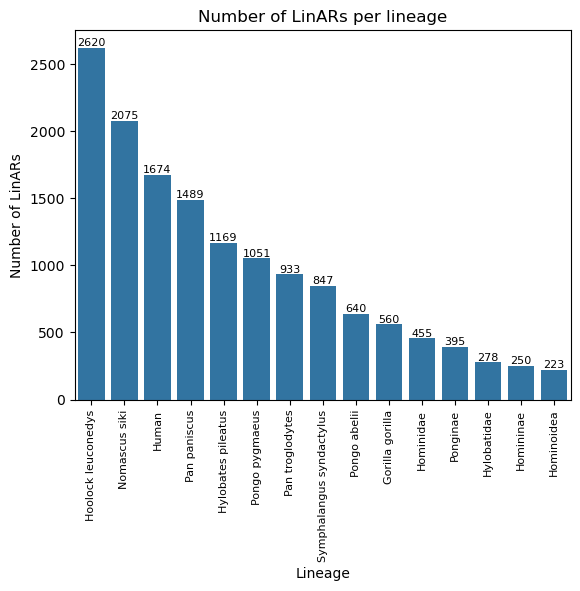

                Lineage_name  count
0         Hoolock leuconedys   2620
1              Nomascus siki   2075
2                      Human   1674
3               Pan paniscus   1489
4         Hylobates pileatus   1169
5             Pongo pygmaeus   1051
6            Pan troglodytes    933
7   Symphalangus syndactylus    847
8               Pongo abelii    640
9            Gorilla gorilla    560
10                 Hominidae    455
11                  Ponginae    395
12               Hylobatidae    278
13                 Homininae    250
14                Hominoidea    223
             count
count    15.000000
mean    977.266667
std     717.062108
min     223.000000
25%     425.000000
50%     847.000000
75%    1329.000000
max    2620.000000


In [ ]:
# Number of LinARs per lineage 

# Count and sort in descending order
LinARs_per_lineage = (
    apes_LinARs_df
    .groupby("Lineage_name")[["Chr", "Start", "End"]]
    .size()
    .sort_values(ascending=False)
    .reset_index(name='count')
)


LinARs_per_lineage_plot = sns.barplot(x='Lineage_name', y='count', data=LinARs_per_lineage)
# Annotate bars with counts
for p in LinARs_per_lineage_plot.patches:
    LinARs_per_lineage_plot.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom', fontsize = 8)
LinARs_per_lineage_plot.set_xlabel("Lineage")
LinARs_per_lineage_plot.set_ylabel("Number of LinARs")
LinARs_per_lineage_plot.set_title("Number of LinARs per lineage")
plt.xticks(rotation = 90, fontsize = 8)
plt.show()


print(LinARs_per_lineage)
print(LinARs_per_lineage.describe())



### Number of shared accelerated regions

                          Gorilla gorilla  Hominidae  Homininae  Hominoidea  \
Gorilla gorilla                     560.0       16.0       11.0         8.0   
Hominidae                            16.0      455.0       14.0         3.0   
Homininae                            11.0       14.0      250.0         8.0   
Hominoidea                            8.0        3.0        8.0       223.0   
Hoolock leuconedys                   27.0       20.0       13.0         4.0   
Human                                71.0       27.0       19.0         3.0   
Hylobates pileatus                   36.0       21.0        7.0         5.0   
Hylobatidae                          14.0       34.0       16.0        10.0   
Nomascus siki                        28.0       33.0       15.0         4.0   
Pan paniscus                         41.0       25.0       28.0        15.0   
Pan troglodytes                      45.0       21.0       10.0         1.0   
Ponginae                             20.0       18.0

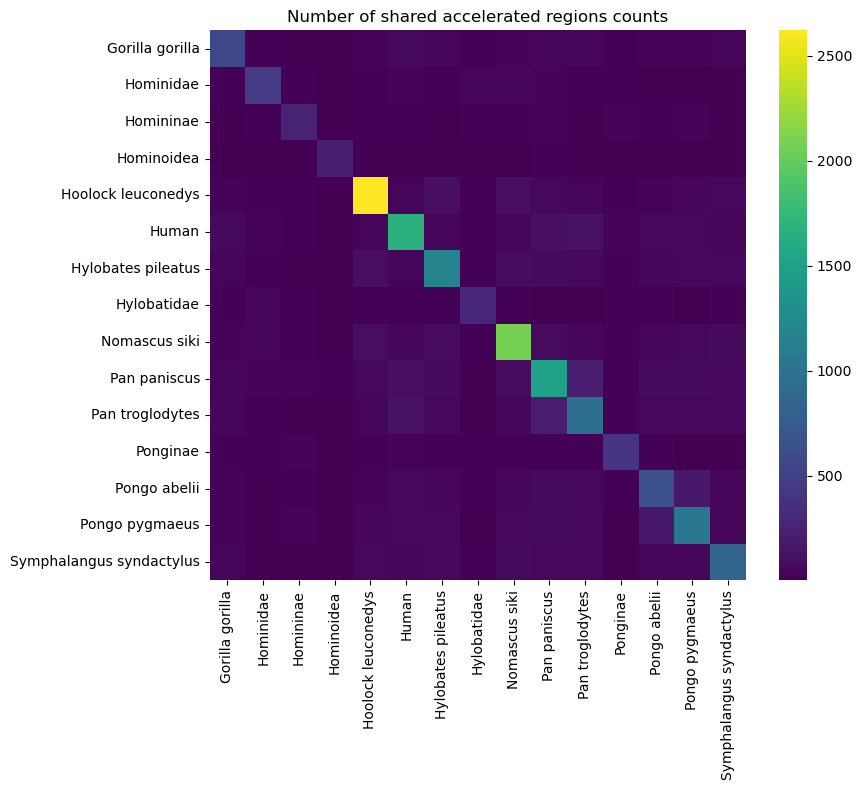

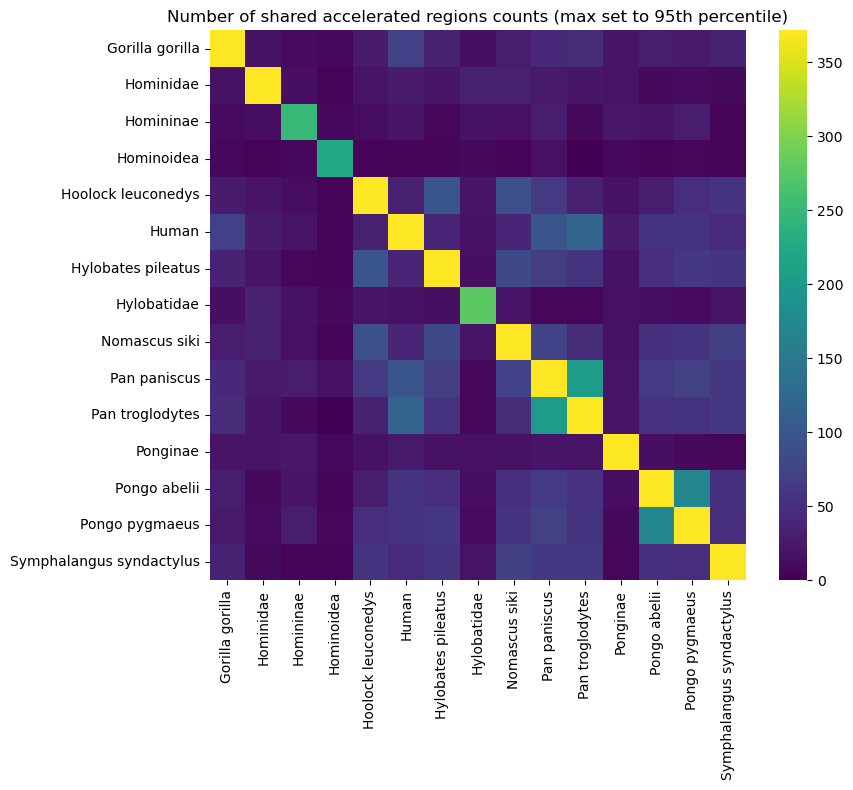

                          Gorilla gorilla  Hominidae  Homininae  Hominoidea  \
Gorilla gorilla                  1.000000   0.028571   0.019643    0.014286   
Hominidae                        0.035165   1.000000   0.030769    0.006593   
Homininae                        0.044000   0.056000   1.000000    0.032000   
Hominoidea                       0.035874   0.013453   0.035874    1.000000   
Hoolock leuconedys               0.010305   0.007634   0.004962    0.001527   
Human                            0.042413   0.016129   0.011350    0.001792   
Hylobates pileatus               0.030796   0.017964   0.005988    0.004277   
Hylobatidae                      0.050360   0.122302   0.057554    0.035971   
Nomascus siki                    0.013494   0.015904   0.007229    0.001928   
Pan paniscus                     0.027535   0.016790   0.018805    0.010074   
Pan troglodytes                  0.048232   0.022508   0.010718    0.001072   
Ponginae                         0.050633   0.045570

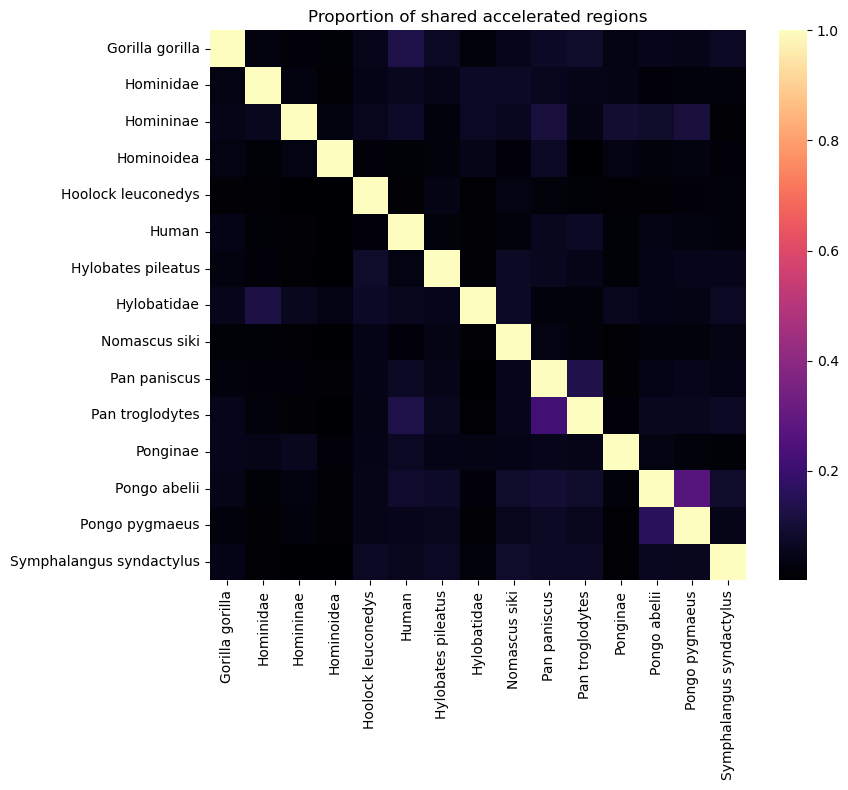

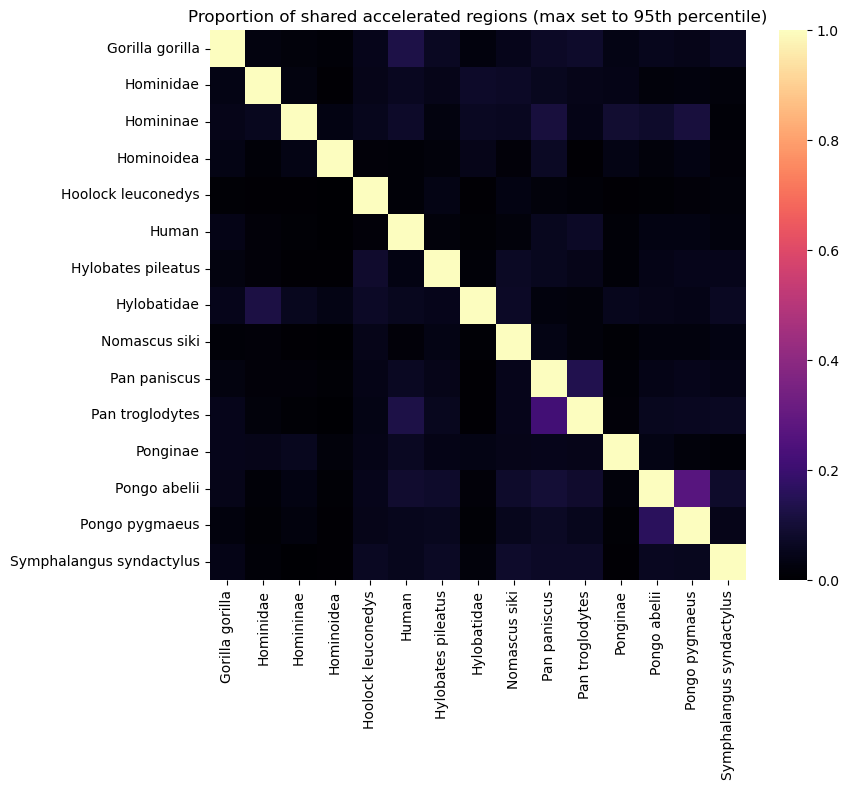

In [58]:
# Heatmap of number of shared accelerated regions between lineages


# Make a dictionary of sets of coordinates for each lineage
lineage_coords = {
    lineage: set(zip(subdf["Chr"], subdf["Start"], subdf["End"]))
    for lineage, subdf in apes_LinARs_df.groupby("Lineage_name")
}

lineages = sorted(lineage_coords.keys())

# Initialize empty matrix for shared counts
shared_matrix = pd.DataFrame(index=lineages, columns=lineages, dtype=int)

# Fill the matrix
for i in lineages:
    for j in lineages:
        shared = lineage_coords[i] & lineage_coords[j]  # intersection of coordinates
        shared_matrix.loc[i, j] = len(shared)


# Normalization (proportion of A’s own LinARs are shared with B) 
lineage_totals = {lineage: len(coords) for lineage, coords in lineage_coords.items()} #how many LinARs in each lineage 
shared_prop = shared_matrix.div(pd.Series(lineage_totals), axis=0)

# Determine reasonable vmin/vmax based (ignore extreme outliers)
vmax_raw = np.percentile(shared_matrix.values, 95)
vmax_normalized = np.percentile(shared_prop.values, 95)  


# Plot raw counts heatmap 
print(shared_matrix)

plt.figure(figsize=(9, 8))
sns.heatmap(shared_matrix, cmap="viridis")
plt.title("Number of shared accelerated regions counts")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 8))
sns.heatmap(shared_matrix, cmap="viridis", vmin=0, vmax=vmax_raw)
plt.title("Number of shared accelerated regions counts (max set to 95th percentile)")
plt.tight_layout()
plt.show()

# Plot normalized heatmap 
print(shared_prop)

plt.figure(figsize=(9, 8))
sns.heatmap(shared_prop, cmap="magma")
plt.title("Proportion of shared accelerated regions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 8))
sns.heatmap(shared_prop, cmap="magma", vmin=0, vmax=vmax_normalized)
plt.title("Proportion of shared accelerated regions (max set to 95th percentile)")
plt.tight_layout()
plt.show()


### ARs lengths

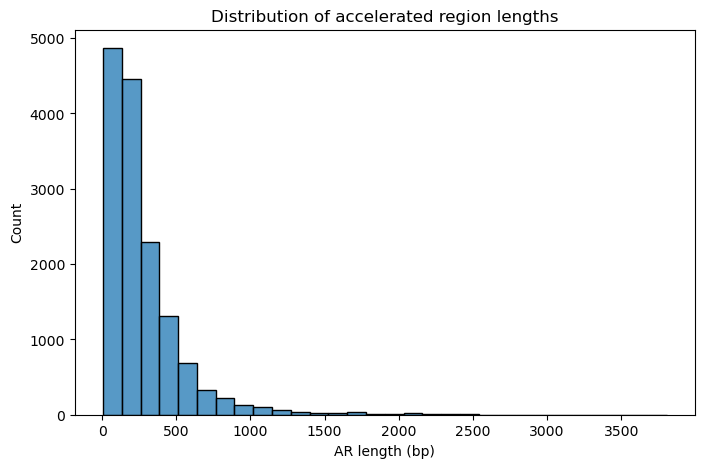

count    14659.000000
mean       271.514564
std        267.713731
min          6.000000
25%        107.000000
50%        192.000000
75%        342.000000
max       3805.000000
Name: Length, dtype: float64


In [60]:
# Distribution of LinAR lengths
apes_LinARs_df = apes_LinARs_df.copy()
apes_LinARs_df["Length"] = apes_LinARs_df["End"] - apes_LinARs_df["Start"]

plt.figure(figsize=(8,5))
sns.histplot(apes_LinARs_df["Length"], bins=30)
plt.xlabel("AR length (bp)")
plt.ylabel("Count")
plt.title("Distribution of accelerated region lengths")
plt.show()

print(apes_LinARs_df["Length"].describe())

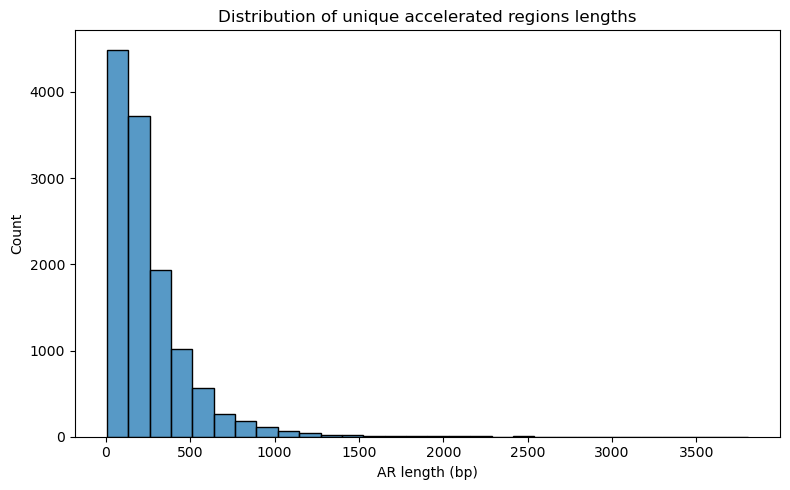

count    12498.000000
mean       254.317491
std        241.874978
min          6.000000
25%         99.000000
50%        182.000000
75%        323.000000
max       3805.000000
Name: Length, dtype: float64


In [ ]:
# Same but only count each AR once

# Drop duplicate coordinates (same region appearing in multiple lineages)
unique_apes_LinARs = apes_LinARs_df.drop_duplicates(subset=["Chr", "Start", "End"])

plt.figure(figsize=(8, 5))
sns.histplot(unique_apes_LinARs["Length"], bins=30)
plt.xlabel("AR length (bp)")
plt.ylabel("Count")
plt.title("Distribution of unique accelerated regions lengths")
plt.tight_layout()
plt.show()

print(unique_LinARs["Length"].describe())


### Number of LinARs across chromosomes

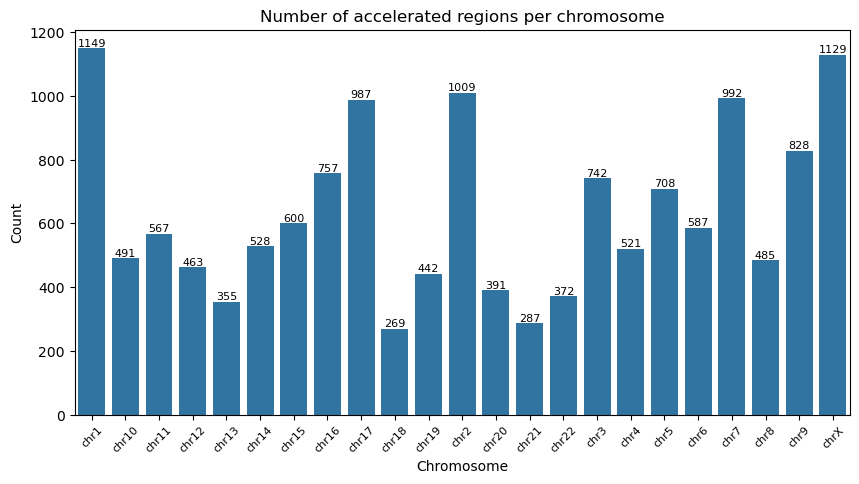

count      23.000000
mean      637.347826
std       267.401402
min       269.000000
25%       452.500000
50%       567.000000
75%       792.500000
max      1149.000000
dtype: float64


In [ ]:
# Number of LinARs per chromosome (include multiple count of regions that exist in multiple lineages)

LinARs_per_chromosome = apes_LinARs_df.groupby("Chr").size()       

LinARs_per_chromosome_df = (LinARs_per_chromosome.reset_index(name="count"))

plt.figure(figsize=(10, 5))
chrom_plot = sns.barplot(x="Chr", y="count", data=LinARs_per_chromosome_df)
for p in chrom_plot.patches:
    chrom_plot.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize = 8
    )
plt.xlabel("Chromosome")
plt.ylabel("Count")
plt.title("Number of accelerated regions per chromosome")
plt.xticks(rotation=45, fontsize=8)
plt.show()

print(LinARs_per_chromosome.describe())

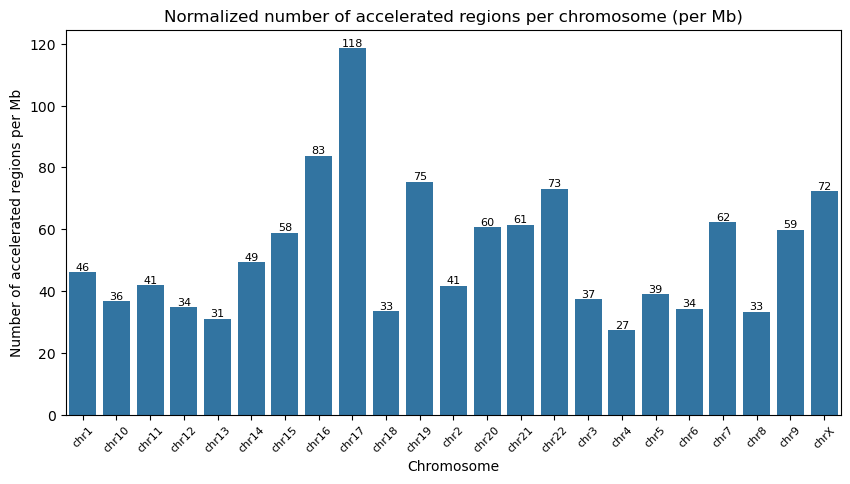

count     23.000000
mean      52.738333
std       21.766450
min       27.390123
25%       35.718694
50%       46.152656
75%       61.848722
max      118.547963
dtype: float64


In [ ]:
# Number of LinARs per chromosome normalized by chromosome length

chrom_lengths = {
    "chr1": 248956422,
    "chr2": 242193529,
    "chr3": 198295559,
    "chr4": 190214555,
    "chr5": 181538259,
    "chr6": 170805979,
    "chr7": 159345973,
    "chr8": 145138636,
    "chr9": 138394717,
    "chr10": 133797422,
    "chr11": 135086622,
    "chr12": 133275309,
    "chr13": 114364328,
    "chr14": 107043718,
    "chr15": 101991189,
    "chr16": 90338345,
    "chr17": 83257441,
    "chr18": 80373285,
    "chr19": 58617616,
    "chr20": 64444167,
    "chr21": 46709983,
    "chr22": 50818468,
    "chrX": 156040895,
}

LinARs_per_chromosome_norm = LinARs_per_chromosome / pd.Series(chrom_lengths) * 1e7


LinARs_per_chromosome_norm_df = (LinARs_per_chromosome_norm.reset_index(name="count").rename(columns={"index": "Chr"}))

plt.figure(figsize=(10, 5))
chrom_plot = sns.barplot(x="Chr", y="count", data=LinARs_per_chromosome_norm_df)
for p in chrom_plot.patches:
    chrom_plot.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize = 8
    )
plt.xlabel("Chromosome")
plt.ylabel("Number of accelerated regions per 10 Mb")
plt.title("Normalized number of accelerated regions per chromosome (per 10 Mb)")
plt.xticks(rotation=45, fontsize=8)
plt.show()


print(LinARs_per_chromosome_norm.describe())


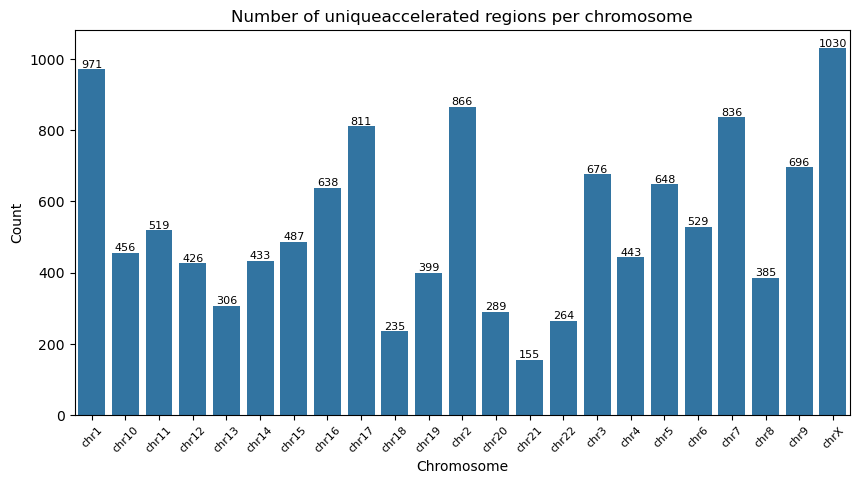

count      23.000000
mean      543.391304
std       241.246712
min       155.000000
25%       392.000000
50%       487.000000
75%       686.000000
max      1030.000000
dtype: float64


In [74]:
# Number of unique accelerated regions per chromosome  (only count each region once)


unique_LinARs_per_chromosome = apes_LinARs_df.drop_duplicates(subset=["Chr", "Start", "End"]).groupby("Chr").size()

unique_LinARs_per_chromosome_df = (unique_LinARs_per_chromosome.reset_index(name="count"))

plt.figure(figsize=(10, 5))
chrom_plot = sns.barplot(x="Chr", y="count", data=unique_LinARs_per_chromosome_df)
for p in chrom_plot.patches:
    chrom_plot.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize = 8
    )
plt.xlabel("Chromosome")
plt.ylabel("Count")
plt.title("Number of uniqueaccelerated regions per chromosome")
plt.xticks(rotation=45, fontsize=8)
plt.show()

print(unique_LinARs_per_chromosome.describe())



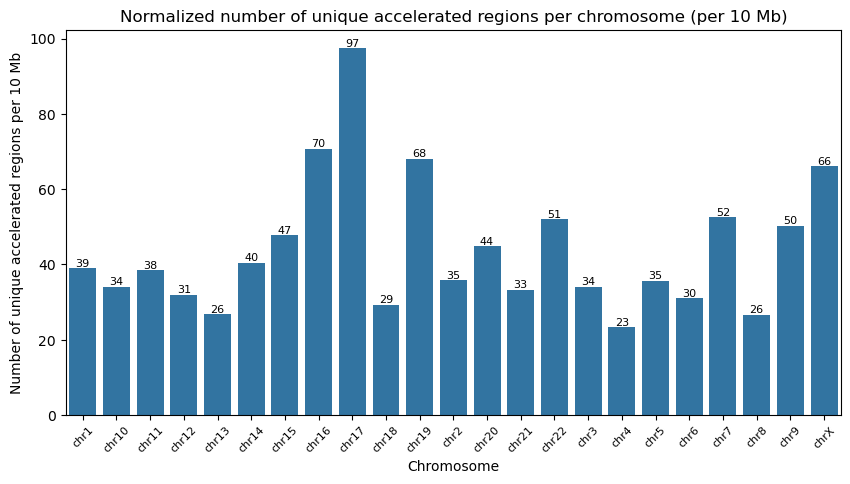

count    23.000000
mean     43.862345
std      17.705961
min      23.289490
25%      32.573697
50%      38.419793
75%      51.120278
max      97.408711
dtype: float64


In [ ]:
# Number of unique accelerated regions per chromosome normalized by chromosome length


unique_LinARs_per_chromosome_norm = unique_LinARs_per_chromosome / pd.Series(chrom_lengths) * 1e7

unique_LinARs_per_chromosome_norm_df = (unique_LinARs_per_chromosome_norm.reset_index(name="count").rename(columns={"index": "Chr"}))

plt.figure(figsize=(10, 5))
chrom_plot = sns.barplot(x="Chr", y="count", data=unique_LinARs_per_chromosome_norm_df)
for p in chrom_plot.patches:
    chrom_plot.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize = 8
    )
plt.xlabel("Chromosome")
plt.ylabel("Number of unique accelerated regions per 10 Mb")
plt.title("Normalized number of unique accelerated regions per chromosome (per 10 Mb)")
plt.xticks(rotation=45, fontsize=8)
plt.show()


print(unique_LinARs_per_chromosome_norm.describe())


### Distribution of ARs across chromosomes

In [132]:
# Window ARs count 

apes_LinARs_df = apes_LinARs_df.sort_values(by=["Chr", "Start"])
apes_LinARs_window_df = apes_LinARs_df.rename(columns={
    'Chr': 'chrom',
    'Start': 'start',
    'End': 'end'
})
# Count number of accelreated regions in chromosome windows
@window(size=100000)  # 100000 bp windows
def multiple_stats(df):
    return dict(total_length=(df.end-df.start).sum(), interval_count=len(df), mean_length=(df.end-df.start).mean())
    
# Group by chromosome and count intervals in windows
apes_result = apes_LinARs_window_df.groupby('chrom').apply(multiple_stats).reset_index(drop=True, level=-1).reset_index()

print(apes_result)

      chrom      start        end  total_length  interval_count  mean_length
0      chr1          0     100000            97               1         97.0
1      chr1     100000     200000             0               0          NaN
2      chr1     200000     300000             0               0          NaN
3      chr1     300000     400000             0               0          NaN
4      chr1     400000     500000             0               0          NaN
...     ...        ...        ...           ...             ...          ...
30207  chrX  155600000  155700000             0               0          NaN
30208  chrX  155700000  155800000             0               0          NaN
30209  chrX  155800000  155900000           582               4        145.5
30210  chrX  155900000  156000000             0               0          NaN
30211  chrX  156000000  156100000            97               2         48.5

[30212 rows x 6 columns]


/var/folders/pz/y0tgvym13cg8yjfc14z454cr0000gn/T/ipykernel_31104/2584610589.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  apes_result = apes_LinARs_window_df.groupby('chrom').apply(multiple_stats).reset_index(drop=True, level=-1).reset_index()


/var/folders/pz/y0tgvym13cg8yjfc14z454cr0000gn/T/ipykernel_31104/871540506.py:29: UserWarning: The palette list has more values (25) than needed (23), which may not be intended.
  chrom_plot = sns.lineplot(


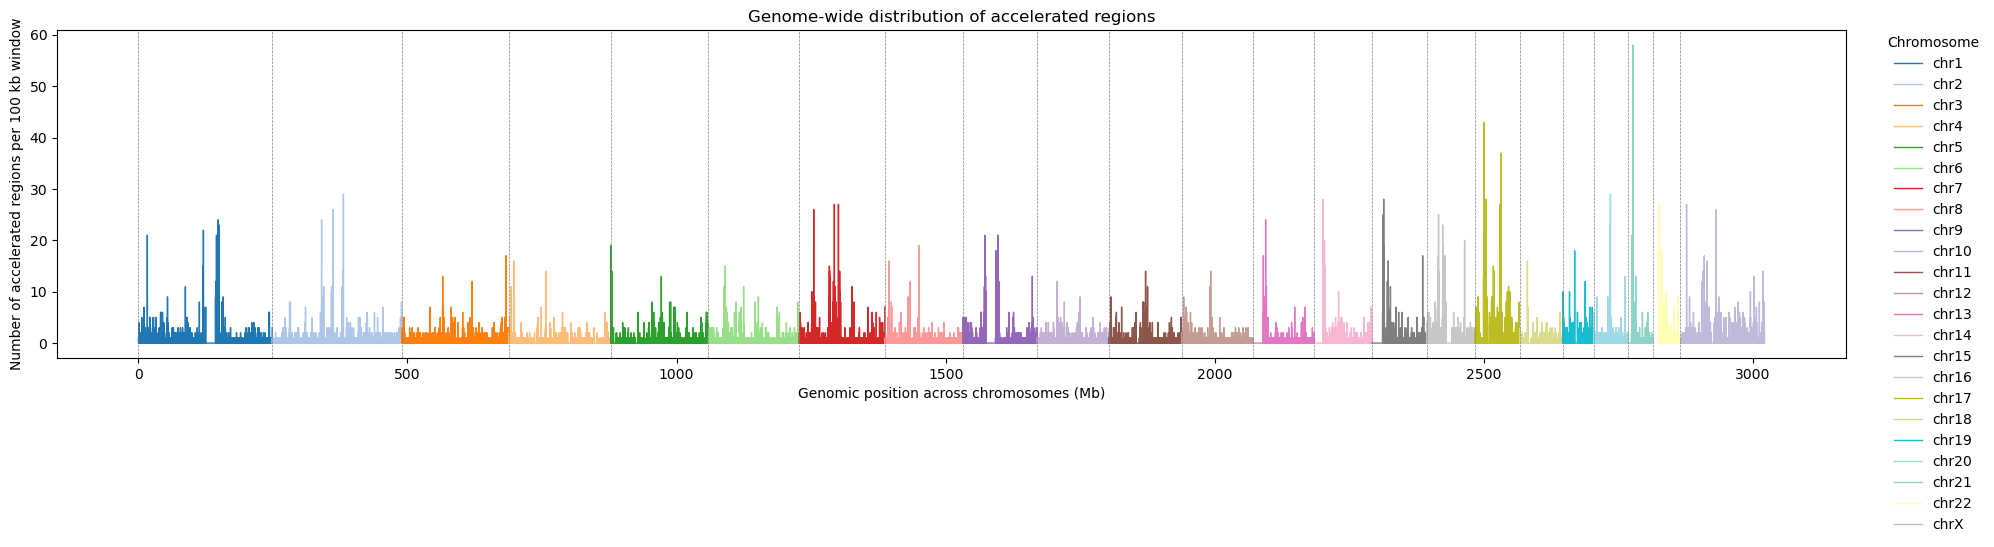

In [133]:
# Plot genome-wide distribution of accelerated regions across chromosomes

apes_plot_df = apes_result.copy()

# Convert start coordinates to megabases
apes_plot_df["start_Mb"] = apes_plot_df["start"] / 1e6

# remove "chr" prefix for numeric sorting
def chr_remove_prefix(chrom):
    chrom = chrom.replace("chr", "")
    if chrom.isdigit():
        return int(chrom)
    elif chrom == "X":
        return 100

# Sort chromosomes numerically
chrom_order = sorted(apes_plot_df["chrom"].unique(), key=chr_remove_prefix)

# Compute chromosome offsets for genome-wide x-axis
chrom_lengths = apes_plot_df.groupby("chrom")["end"].max().reindex(chrom_order)
chrom_offsets = chrom_lengths.cumsum() - chrom_lengths # cumulative sum of all previous chromosome lengths
apes_plot_df["offset_Mb"] = apes_plot_df["chrom"].map(chrom_offsets) / 1e6  # convert to Mb
apes_plot_df["genome_pos_Mb"] = apes_plot_df["start_Mb"] + apes_plot_df["offset_Mb"] # genome-wide position


# Plot genome-wide distribution
plt.figure(figsize=(20, 5))
palette = sns.color_palette("tab20") + sns.color_palette("Set3", 5)
chrom_plot = sns.lineplot(
    data=apes_plot_df.sort_values("genome_pos_Mb"),
    x="genome_pos_Mb",
    y="interval_count",
    hue="chrom",
    lw=1,
    palette=palette
)
plt.xlabel("Genomic position across chromosomes (Mb)")
plt.ylabel("Number of accelerated regions per 100 kb window")
plt.title("Genome-wide distribution of accelerated regions")

# Add chromosome separators
for offset in apes_plot_df.groupby("chrom")["offset_Mb"].first():
    plt.axvline(offset, color="gray", lw=0.5, linestyle="--")

# Move legend outside the plot
plt.legend(
    title="Chromosome",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    frameon=False
)

plt.tight_layout()
plt.show()


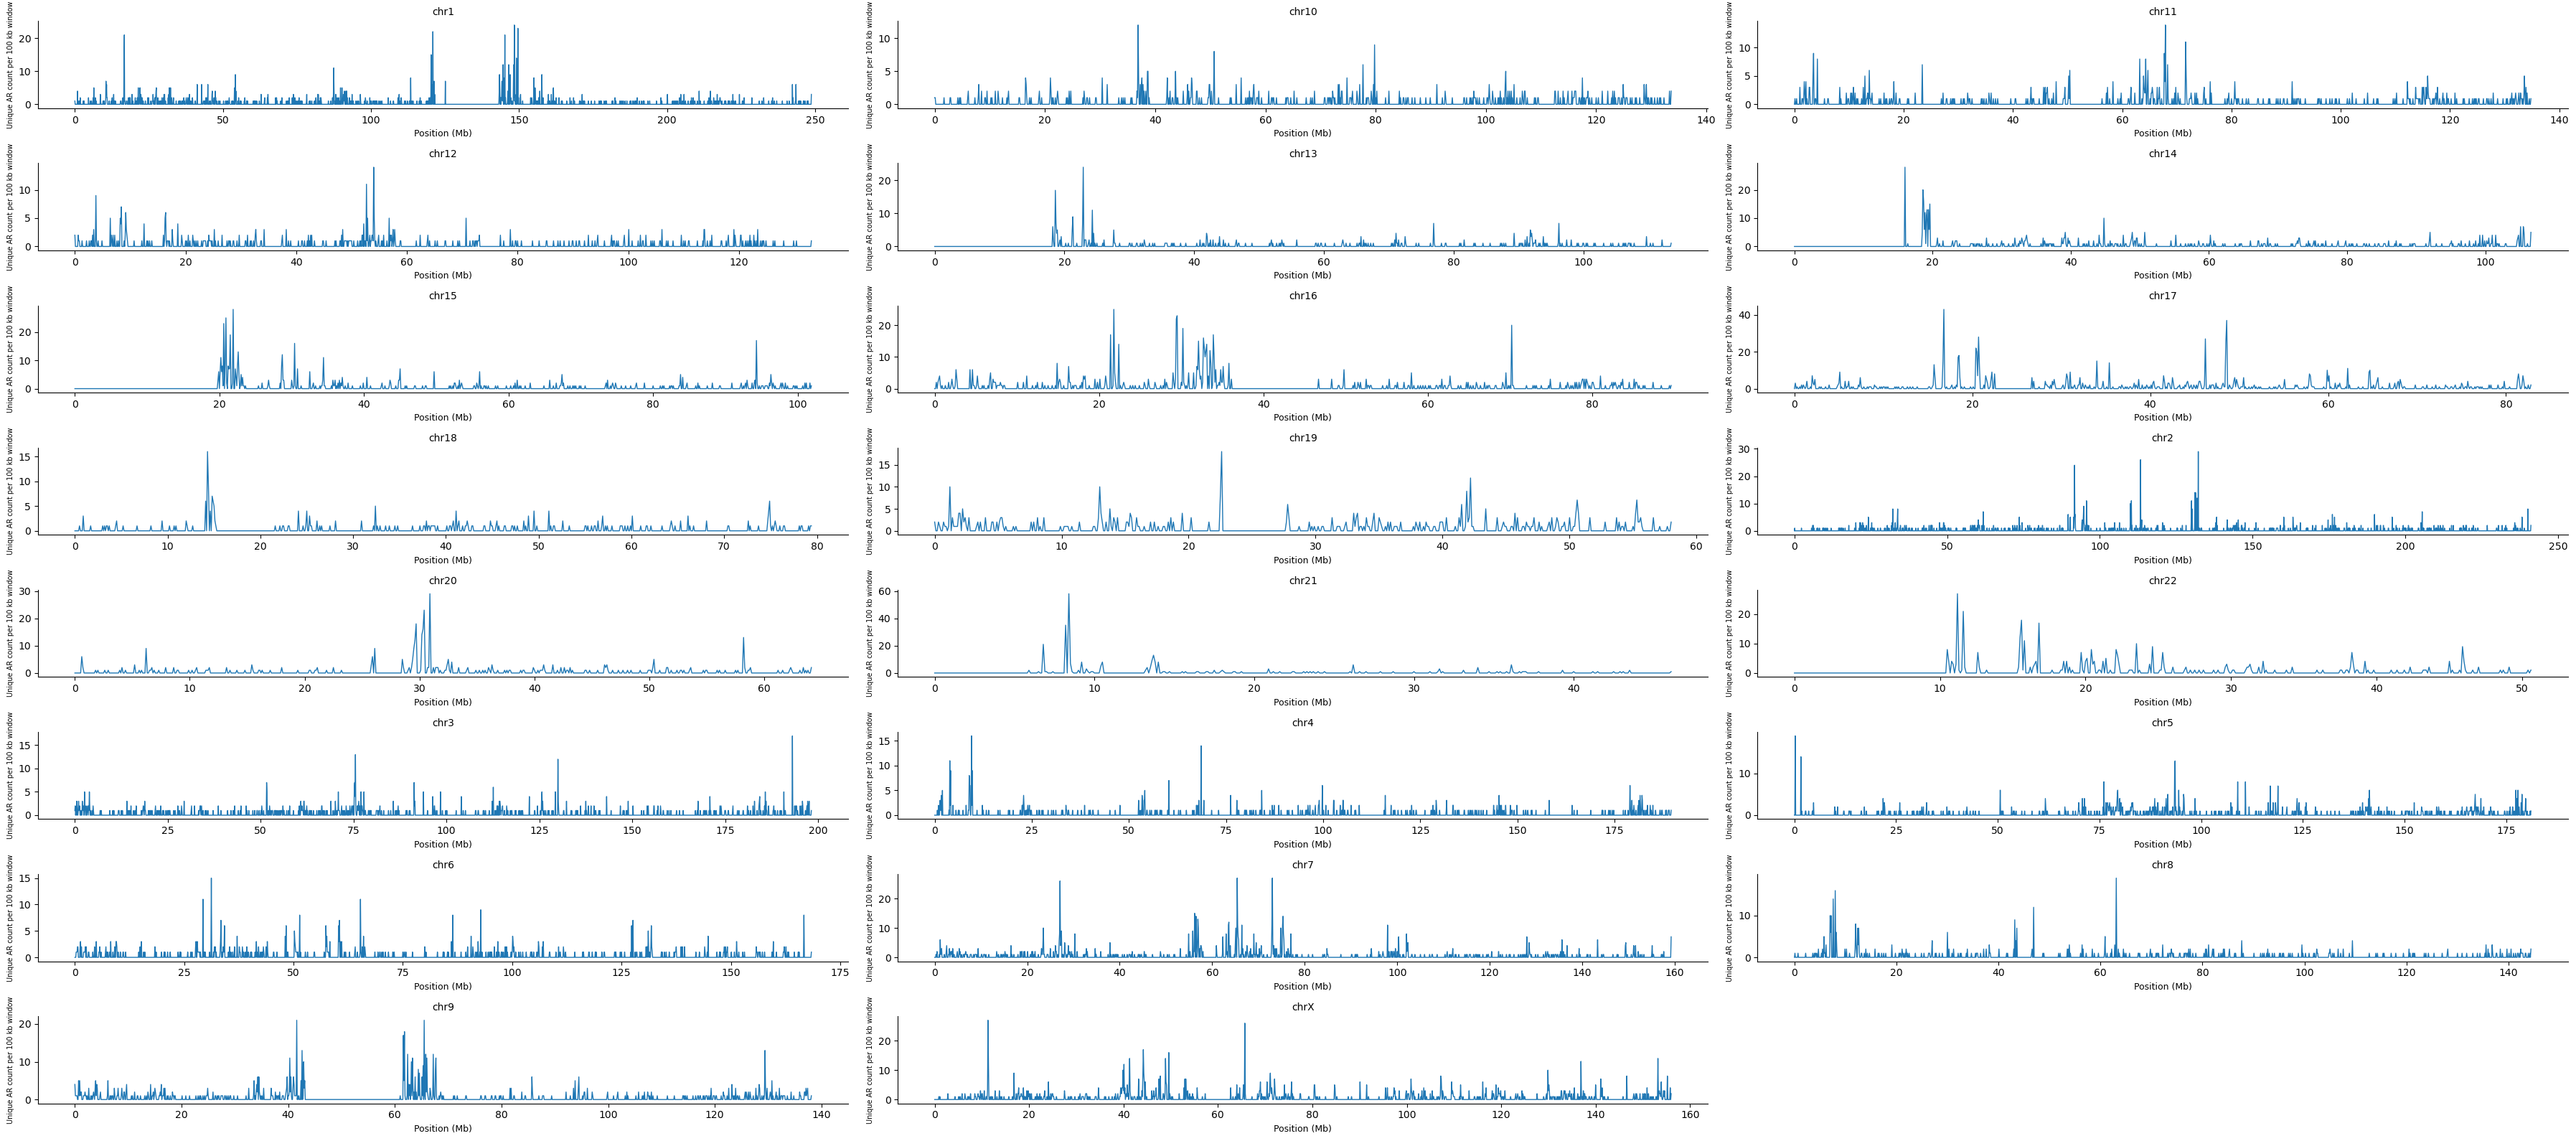

In [134]:
# facet wrap 
chrom_facet_plot = sns.FacetGrid(
    apes_plot_df,
    col="chrom",
    col_wrap=3,  # 3 chromosomes per row
    aspect=6,         
    sharex=False,
    sharey=False,
    height=2          
)
chrom_facet_plot.map_dataframe(sns.lineplot, x="start_Mb", y="interval_count", lw=1)

for ax in chrom_facet_plot.axes.flat:
    ax.set_xlabel("Position (Mb)", fontsize=9)
    ax.set_ylabel("Unique AR count per 100 kb window", fontsize=7)
 
chrom_facet_plot.set_titles(col_template="{col_name}", size=10)

plt.tight_layout()
plt.show()

###  Distribution of unique ARs across chromosomes

In [135]:
# Window ARs count 

# Only include unique accelerated regions
unique_LinARs_df = apes_LinARs_df.drop_duplicates(subset=["Chr", "Start", "End"])

unique_LinARs_df = unique_LinARs_df.sort_values(by=["Chr", "Start"])
apes_LinARs_window_df = unique_LinARs_df.rename(columns={
    'Chr': 'chrom',
    'Start': 'start',
    'End': 'end'
})
# Count number of accelreated regions in chromosome windows
@window(size=100000)  # 100000 bp windows
def multiple_stats(df):
    return dict(total_length=(df.end-df.start).sum(), interval_count=len(df), mean_length=(df.end-df.start).mean())
    
# Group by chromosome and count intervals in windows
apes_result = apes_LinARs_window_df.groupby('chrom').apply(multiple_stats).reset_index(drop=True, level=-1).reset_index()

print(apes_result)

      chrom      start        end  total_length  interval_count  mean_length
0      chr1          0     100000            97               1         97.0
1      chr1     100000     200000             0               0          NaN
2      chr1     200000     300000             0               0          NaN
3      chr1     300000     400000             0               0          NaN
4      chr1     400000     500000             0               0          NaN
...     ...        ...        ...           ...             ...          ...
30207  chrX  155600000  155700000             0               0          NaN
30208  chrX  155700000  155800000             0               0          NaN
30209  chrX  155800000  155900000           582               4        145.5
30210  chrX  155900000  156000000             0               0          NaN
30211  chrX  156000000  156100000            97               2         48.5

[30212 rows x 6 columns]


/var/folders/pz/y0tgvym13cg8yjfc14z454cr0000gn/T/ipykernel_31104/83559899.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  apes_result = apes_LinARs_window_df.groupby('chrom').apply(multiple_stats).reset_index(drop=True, level=-1).reset_index()


/var/folders/pz/y0tgvym13cg8yjfc14z454cr0000gn/T/ipykernel_31104/495814329.py:29: UserWarning: The palette list has more values (25) than needed (23), which may not be intended.
  chrom_plot = sns.lineplot(


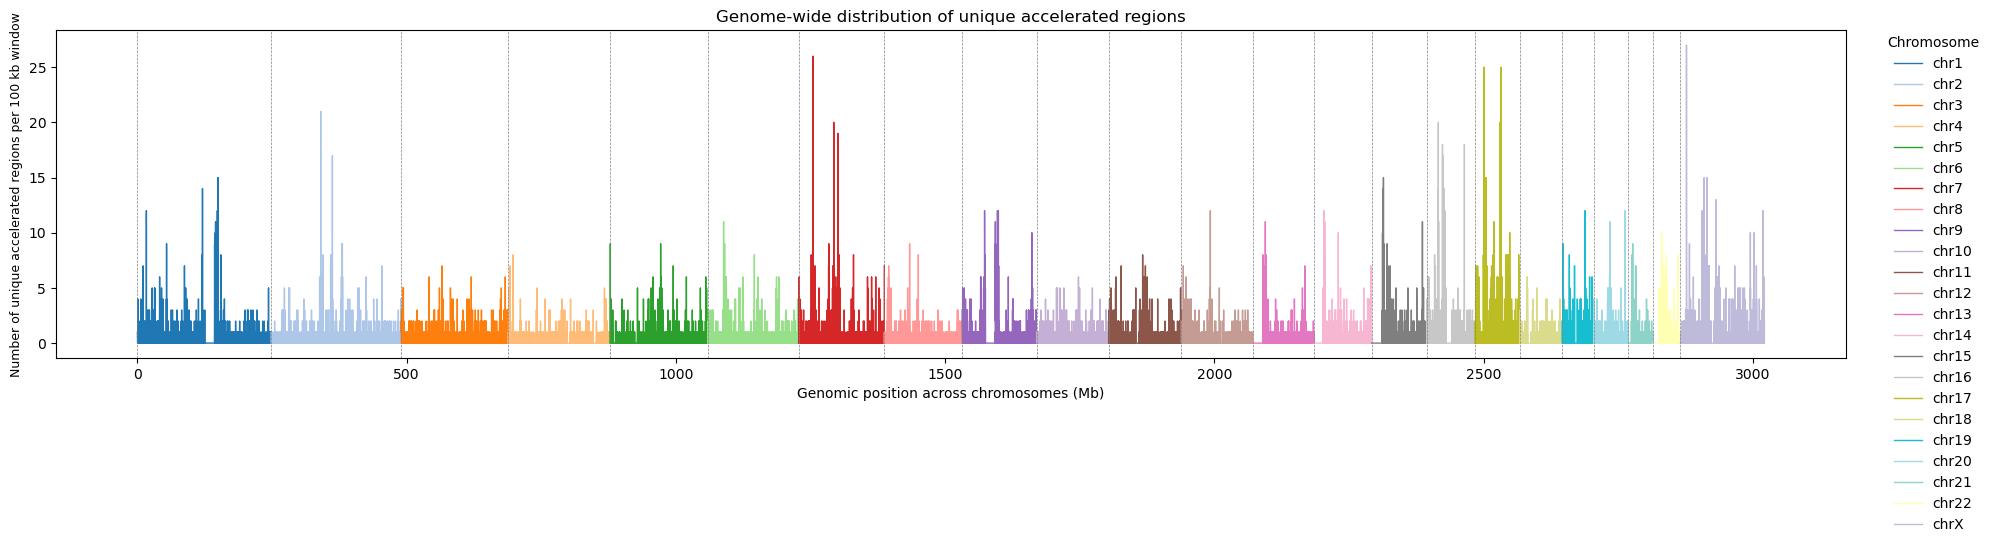

In [139]:
# Plot genome-wide distribution of accelerated regions across chromosomes

apes_plot_df = apes_result.copy()

# Convert start coordinates to megabases
apes_plot_df["start_Mb"] = apes_plot_df["start"] / 1e6

# remove "chr" prefix for numeric sorting
def chr_remove_prefix(chrom):
    chrom = chrom.replace("chr", "")
    if chrom.isdigit():
        return int(chrom)
    elif chrom == "X":
        return 100

# Sort chromosomes numerically
chrom_order = sorted(apes_plot_df["chrom"].unique(), key=chr_remove_prefix)

# Compute chromosome offsets for genome-wide x-axis
chrom_lengths = apes_plot_df.groupby("chrom")["end"].max().reindex(chrom_order)
chrom_offsets = chrom_lengths.cumsum() - chrom_lengths # cumulative sum of all previous chromosome lengths
apes_plot_df["offset_Mb"] = apes_plot_df["chrom"].map(chrom_offsets) / 1e6  # convert to Mb
apes_plot_df["genome_pos_Mb"] = apes_plot_df["start_Mb"] + apes_plot_df["offset_Mb"] # genome-wide position


# Plot genome-wide distribution
plt.figure(figsize=(20, 5))
palette = sns.color_palette("tab20") + sns.color_palette("Set3", 5)
chrom_plot = sns.lineplot(
    data=apes_plot_df.sort_values("genome_pos_Mb"),
    x="genome_pos_Mb",
    y="interval_count",
    hue="chrom",
    lw=1,
    palette=palette
)
plt.xlabel("Genomic position across chromosomes (Mb)")
plt.ylabel("Number of unique accelerated regions per 100 kb window", fontsize = 9)
plt.title("Genome-wide distribution of unique accelerated regions")

# Add chromosome separators
for offset in apes_plot_df.groupby("chrom")["offset_Mb"].first():
    plt.axvline(offset, color="gray", lw=0.5, linestyle="--")

# Move legend outside the plot
plt.legend(
    title="Chromosome",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    frameon=False
)

plt.tight_layout()
plt.show()

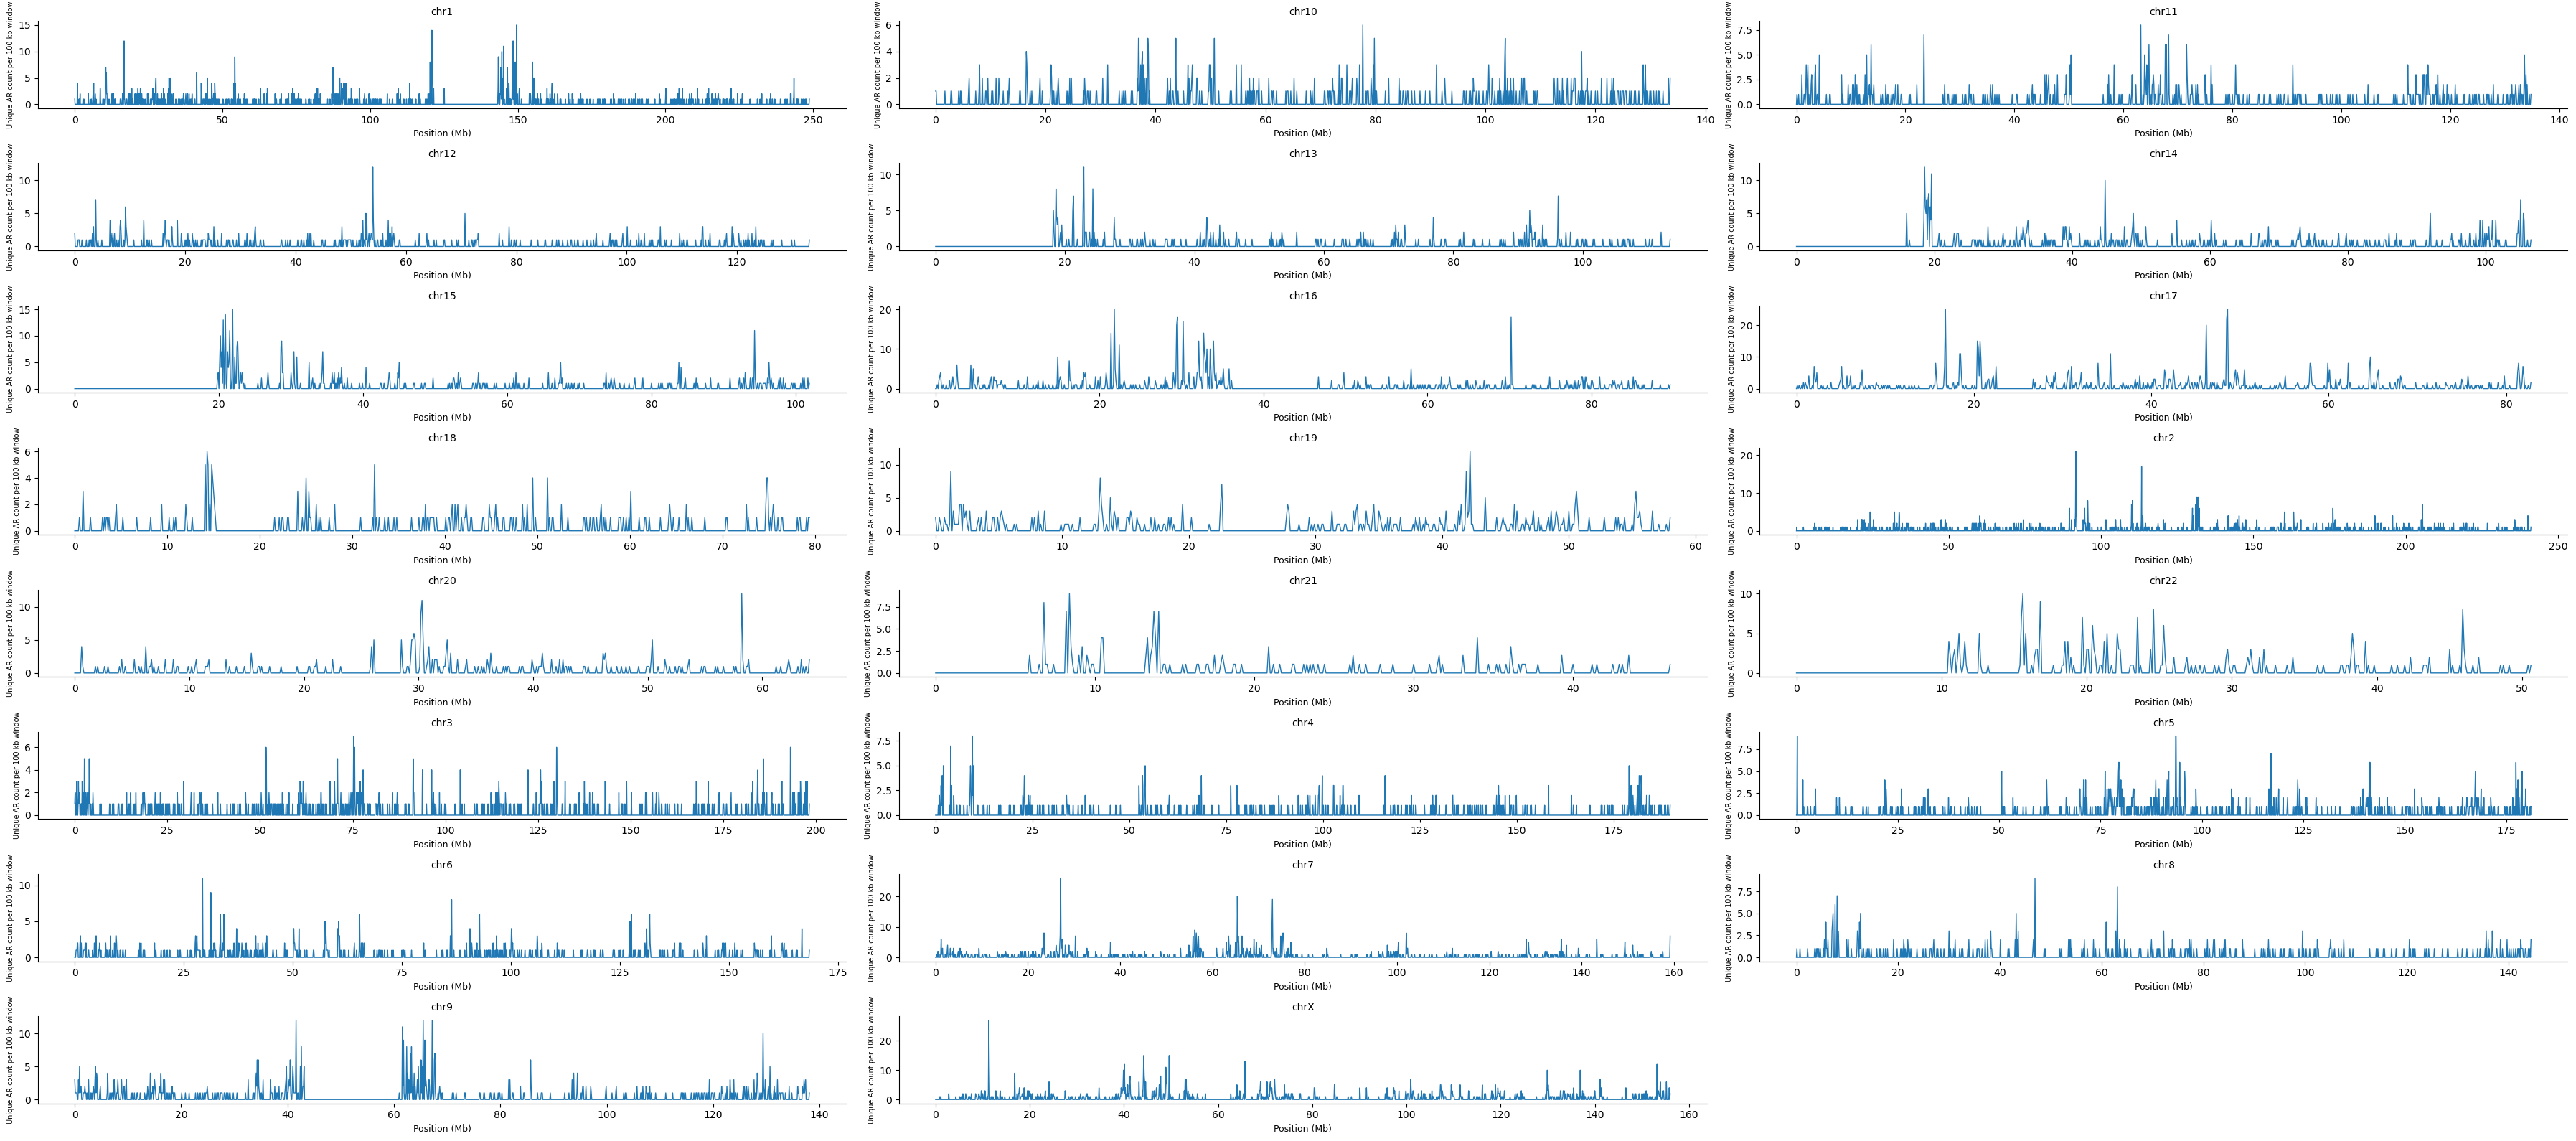

In [140]:
# facet wrap 
chrom_facet_plot = sns.FacetGrid(
    apes_plot_df,
    col="chrom",
    col_wrap=3,  # 3 chromosomes per row
    aspect=6,         
    sharex=False,
    sharey=False,
    height=2          
)
chrom_facet_plot.map_dataframe(sns.lineplot, x="start_Mb", y="interval_count", lw=1)

for ax in chrom_facet_plot.axes.flat:
    ax.set_xlabel("Position (Mb)", fontsize=9)
    ax.set_ylabel("Unique AR count per 100 kb window", fontsize=7)
 
chrom_facet_plot.set_titles(col_template="{col_name}", size=10)

plt.tight_layout()
plt.show()


### Distribution of HARs across chromosomes

In [141]:
# Filter for HARs
human_LinARs_df = apes_LinARs_df[apes_LinARs_df["Lineage_name"] == "Human"].copy()

human_LinARs_df = human_LinARs_df.sort_values(by=["Chr", "Start"])

human_LinARs_window_df = human_LinARs_df.rename(columns={
    'Chr': 'chrom',
    'Start': 'start',
    'End': 'end'
})
# Count number of accelreated regions in chromosome windows
@window(size=100000)  # 100000 bp windows
def multiple_stats(df):
    return dict(total_length=(df.end-df.start).sum(), interval_count=len(df), mean_length=(df.end-df.start).mean())
    
# Group by chromosome and count intervals in windows
human_result = human_LinARs_window_df.groupby('chrom').apply(multiple_stats).reset_index(drop=True, level=-1).reset_index()

print(human_result)




      chrom      start        end  total_length  interval_count  mean_length
0      chr1          0     100000             0               0          NaN
1      chr1     100000     200000             0               0          NaN
2      chr1     200000     300000             0               0          NaN
3      chr1     300000     400000             0               0          NaN
4      chr1     400000     500000             0               0          NaN
...     ...        ...        ...           ...             ...          ...
29430  chrX  149000000  149100000             0               0          NaN
29431  chrX  149100000  149200000             0               0          NaN
29432  chrX  149200000  149300000             0               0          NaN
29433  chrX  149300000  149400000             0               0          NaN
29434  chrX  149400000  149500000           330               1        330.0

[29435 rows x 6 columns]


/var/folders/pz/y0tgvym13cg8yjfc14z454cr0000gn/T/ipykernel_31104/1487312835.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  human_result = human_LinARs_window_df.groupby('chrom').apply(multiple_stats).reset_index(drop=True, level=-1).reset_index()


/var/folders/pz/y0tgvym13cg8yjfc14z454cr0000gn/T/ipykernel_31104/2948368558.py:27: UserWarning: The palette list has more values (25) than needed (23), which may not be intended.
  chrom_plot = sns.lineplot(


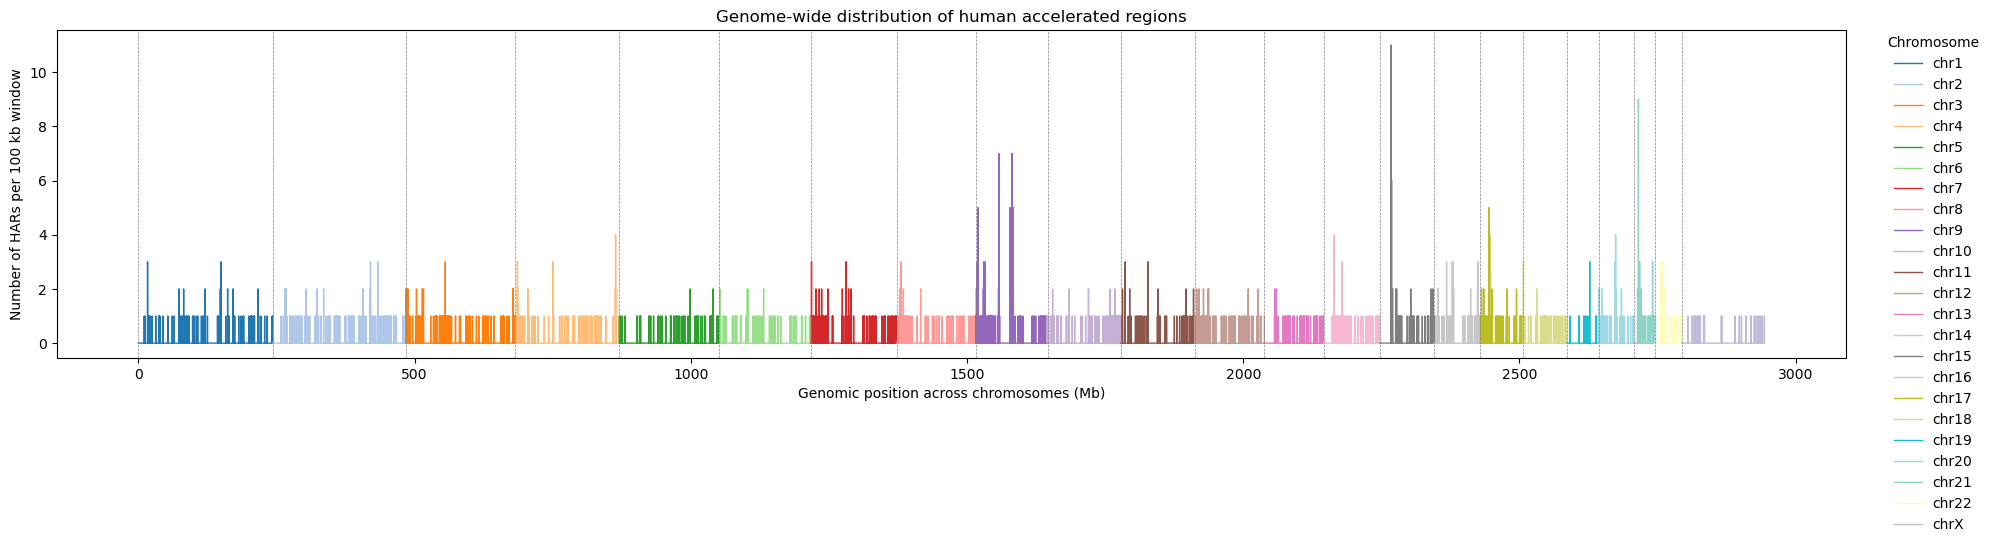

In [ ]:

human_plot_df = human_result.copy()

# Convert start coordinates to megabases
human_plot_df["start_Mb"] = human_plot_df["start"] / 1e6

# remove "chr" prefix for numeric sorting
def chr_remove_prefix(chrom):
    chrom = chrom.replace("chr", "")
    if chrom.isdigit():
        return int(chrom)
    elif chrom == "X":
        return 100

# Sort chromosomes numerically
chrom_order = sorted(human_plot_df["chrom"].unique(), key=chr_remove_prefix)

# Compute chromosome offsets for genome-wide x-axis
chrom_lengths = human_plot_df.groupby("chrom")["end"].max().reindex(chrom_order)
chrom_offsets = chrom_lengths.cumsum() - chrom_lengths # cumulative sum of all previous chromosome lengths
human_plot_df["offset_Mb"] = human_plot_df["chrom"].map(chrom_offsets) / 1e6  # convert to Mb
human_plot_df["genome_pos_Mb"] = human_plot_df["start_Mb"] + human_plot_df["offset_Mb"] # genome-wide position


# Plot genome-wide distribution
plt.figure(figsize=(20, 5))
palette = sns.color_palette("tab20") + sns.color_palette("Set3", 5)
chrom_plot = sns.lineplot(
    data=human_plot_df.sort_values("genome_pos_Mb"),
    x="genome_pos_Mb",
    y="interval_count",
    hue="chrom",
    lw=1,
    palette=palette
)
plt.xlabel("Genomic position across chromosomes (Mb)")
plt.ylabel("Number of HARs per 100 kb window")
plt.title("Genome-wide distribution of human accelerated regions")

# Add chromosome separators
for offset in human_plot_df.groupby("chrom")["offset_Mb"].first():
    plt.axvline(offset, color="gray", lw=0.5, linestyle="--")

# Move legend outside the plot
plt.legend(
    title="Chromosome",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    frameon=False
)

plt.tight_layout()
plt.show()


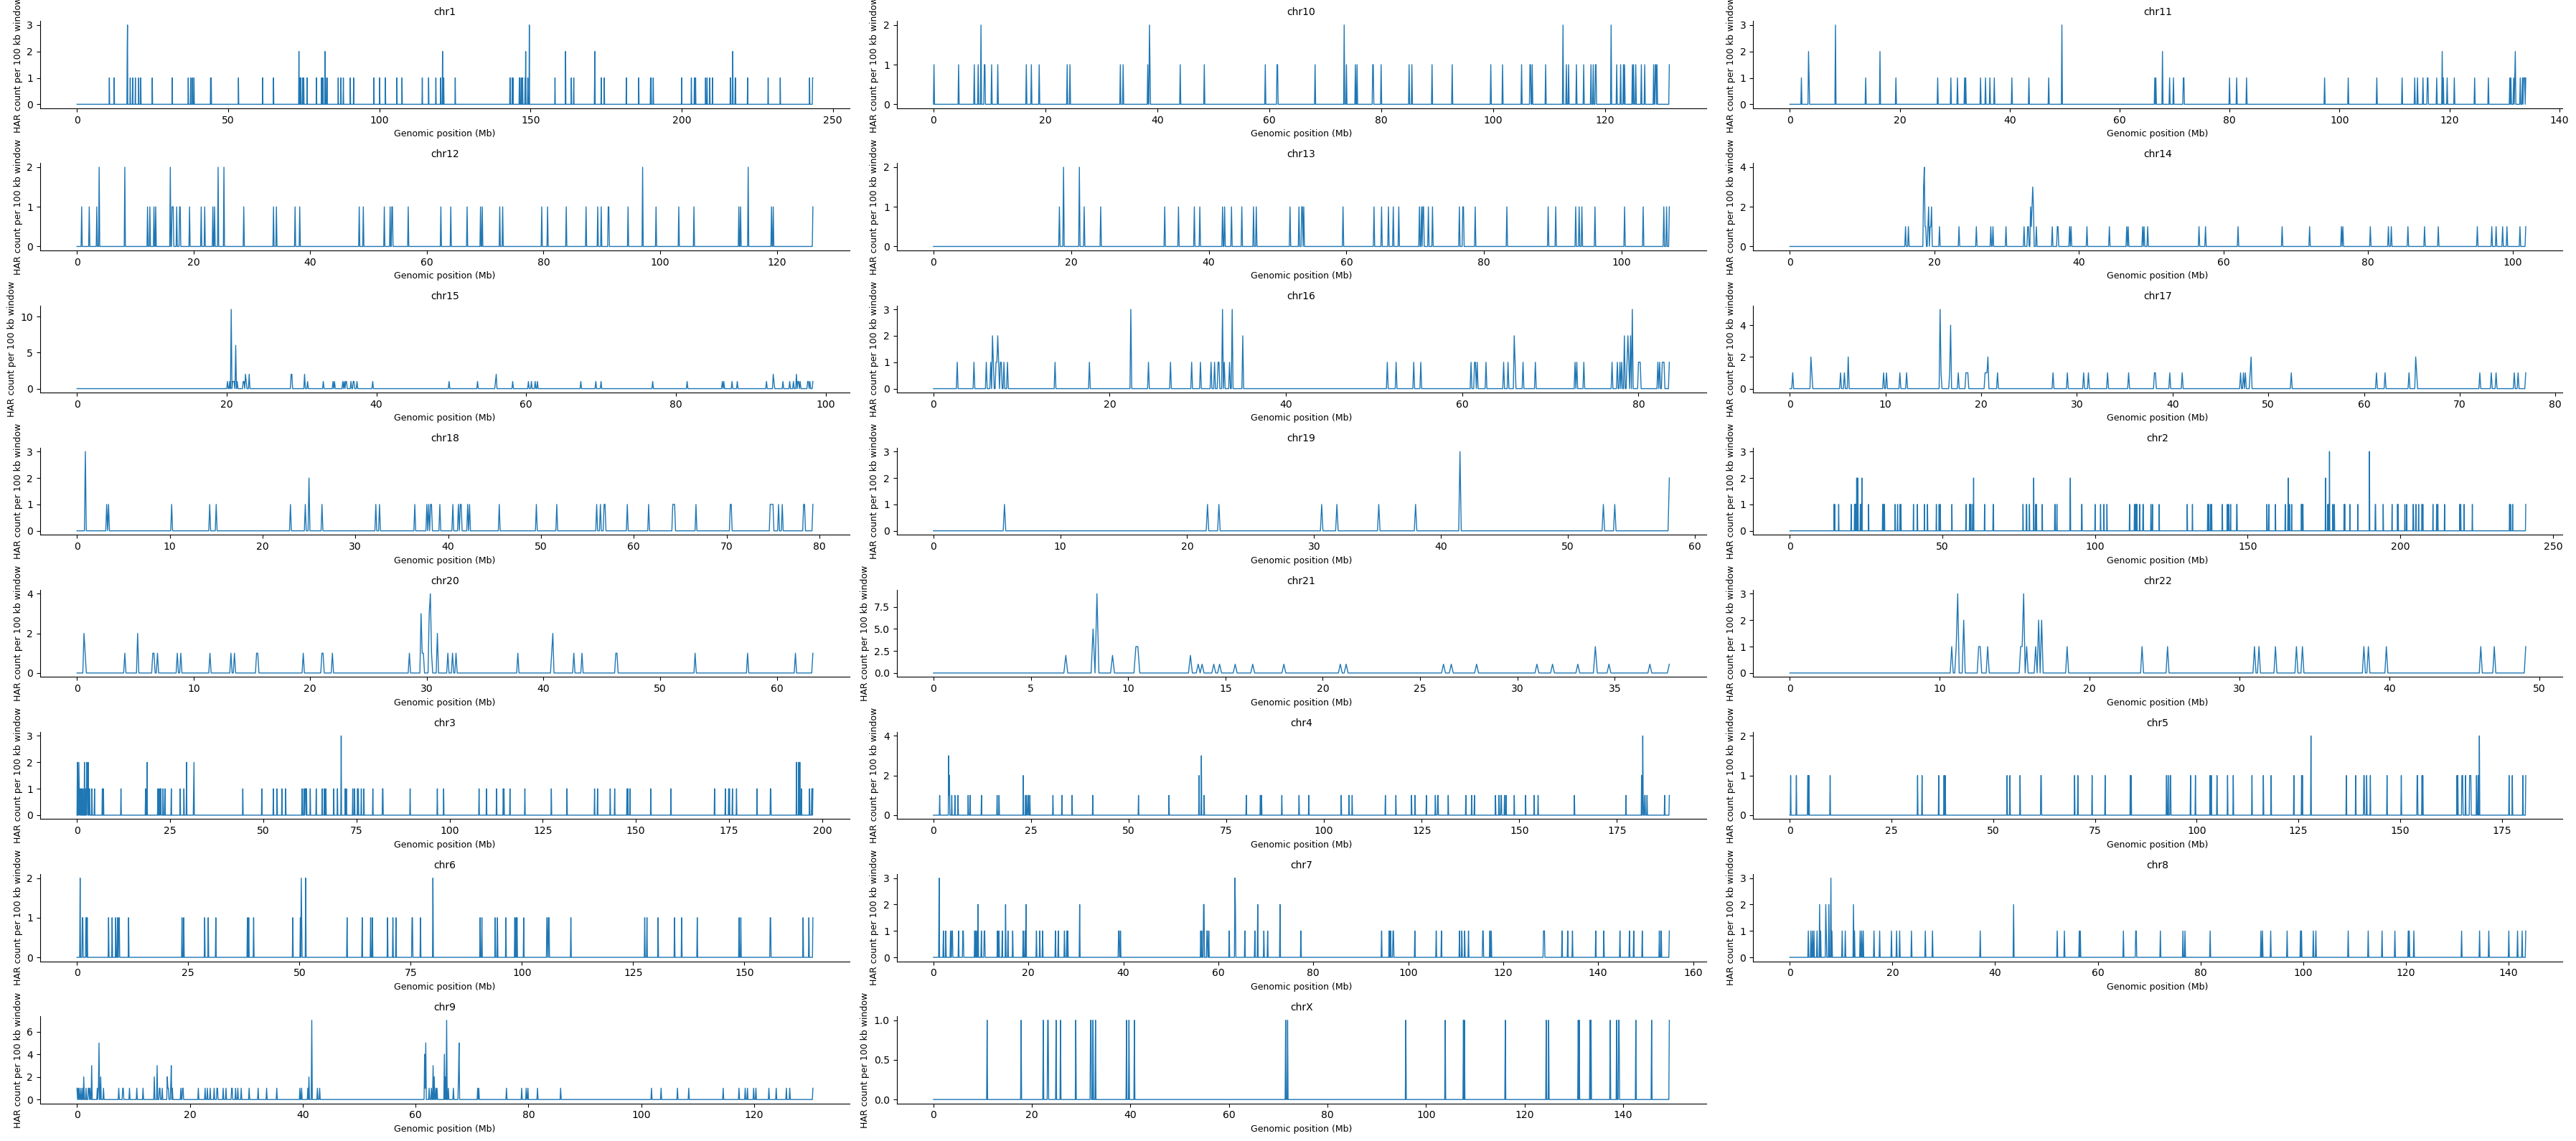

In [143]:
# facet wrap 
chrom_facet_plot = sns.FacetGrid(
    human_plot_df,
    col="chrom",
    col_wrap=3,  # 3 chromosomes per row
    aspect=6,         
    sharex=False,
    sharey=False,
    height=2          
)
chrom_facet_plot.map_dataframe(sns.lineplot, x="start_Mb", y="interval_count", lw=1)

for ax in chrom_facet_plot.axes.flat:
    ax.set_xlabel("Genomic position (Mb)", fontsize=9)
    ax.set_ylabel("HAR count per 100 kb window", fontsize=9)
 
chrom_facet_plot.set_titles(col_template="{col_name}", size=10)

plt.tight_layout()
plt.show()

### Identify hotspots

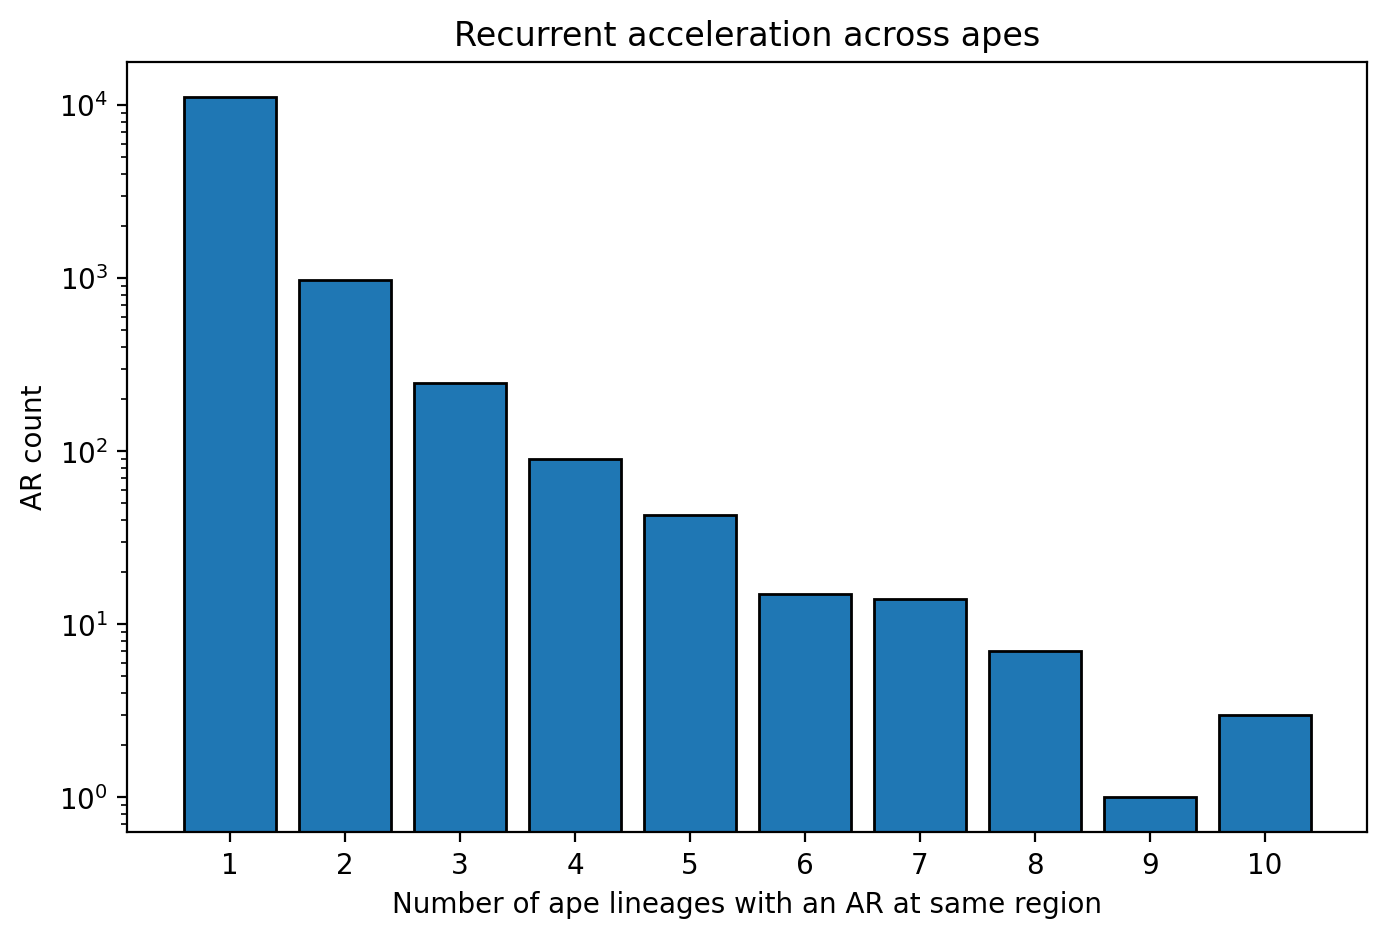

In [212]:
# Count how many accelerated regions appear in 1, 2, ... lineages

overlap_counts = (
    apes_LinARs_df
    .groupby(["Chr", "Start", "End"])["Lineage_name"]
    .nunique()
    .reset_index(name="num_lineages")
)

counts = overlap_counts["num_lineages"].value_counts().sort_index()

# Bar plot
plt.figure(figsize=(8,5))
plt.bar(counts.index, counts.values, edgecolor='black')
plt.xlabel("Number of ape lineages with an AR at same region")
plt.ylabel("AR count")
plt.title("Recurrent acceleration across apes")
plt.xticks(counts.index)  
plt.yscale('log')
plt.show()


        Chr      Start        End  num_lineages
77     chr1   16696391   16696561             3
81     chr1   16700529   16700703             4
82     chr1   16701171   16701330             3
84     chr1   16707284   16707442             3
123    chr1   22092413   22092981             3
...     ...        ...        ...           ...
12057  chrX   75678258   75678530             3
12058  chrX   75678548   75678788             3
12093  chrX   90113305   90113498             3
12102  chrX   95584585   95584745             3
12376  chrX  136976171  136976479             3

[421 rows x 4 columns]


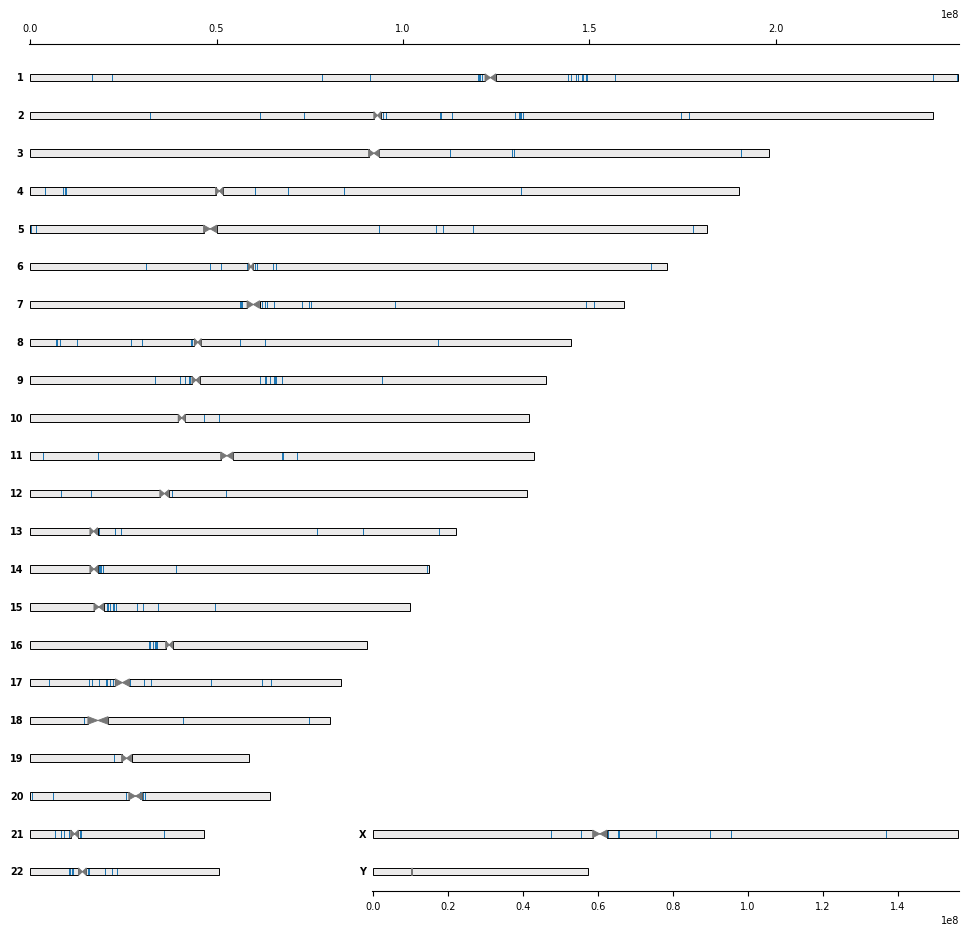

In [153]:
# Identify and visualize recurrent ARs (present in ≥3 apes)

recurrent_ARs = overlap_counts[overlap_counts["num_lineages"] >= 3]  # Filter ARs present in ≥3 apes 
print(recurrent_ARs)

hotspots = [(row.Chr, row.Start, row.End) for row in recurrent_ARs.itertuples(index=False)]
ideogram_plot = gplt.GenomeIdeogram(assembly='hg38') 
ideogram_plot.draw_chromosomes()
ideogram_plot.add_segments(hotspots, facecolor='tab:blue', alpha=0.2)

        Chr      Start        End  num_lineages
0      chr1      25574      25671             1
1      chr1     923836     923972             1
2      chr1     924429     924968             1
3      chr1     937804     937940             1
4      chr1     941924     941989             1
...     ...        ...        ...           ...
12493  chrX  155828704  155828857             1
12494  chrX  155828972  155829067             1
12495  chrX  155829259  155829465             1
12496  chrX  156021733  156021793             1
12497  chrX  156022801  156022838             1

[12498 rows x 4 columns]


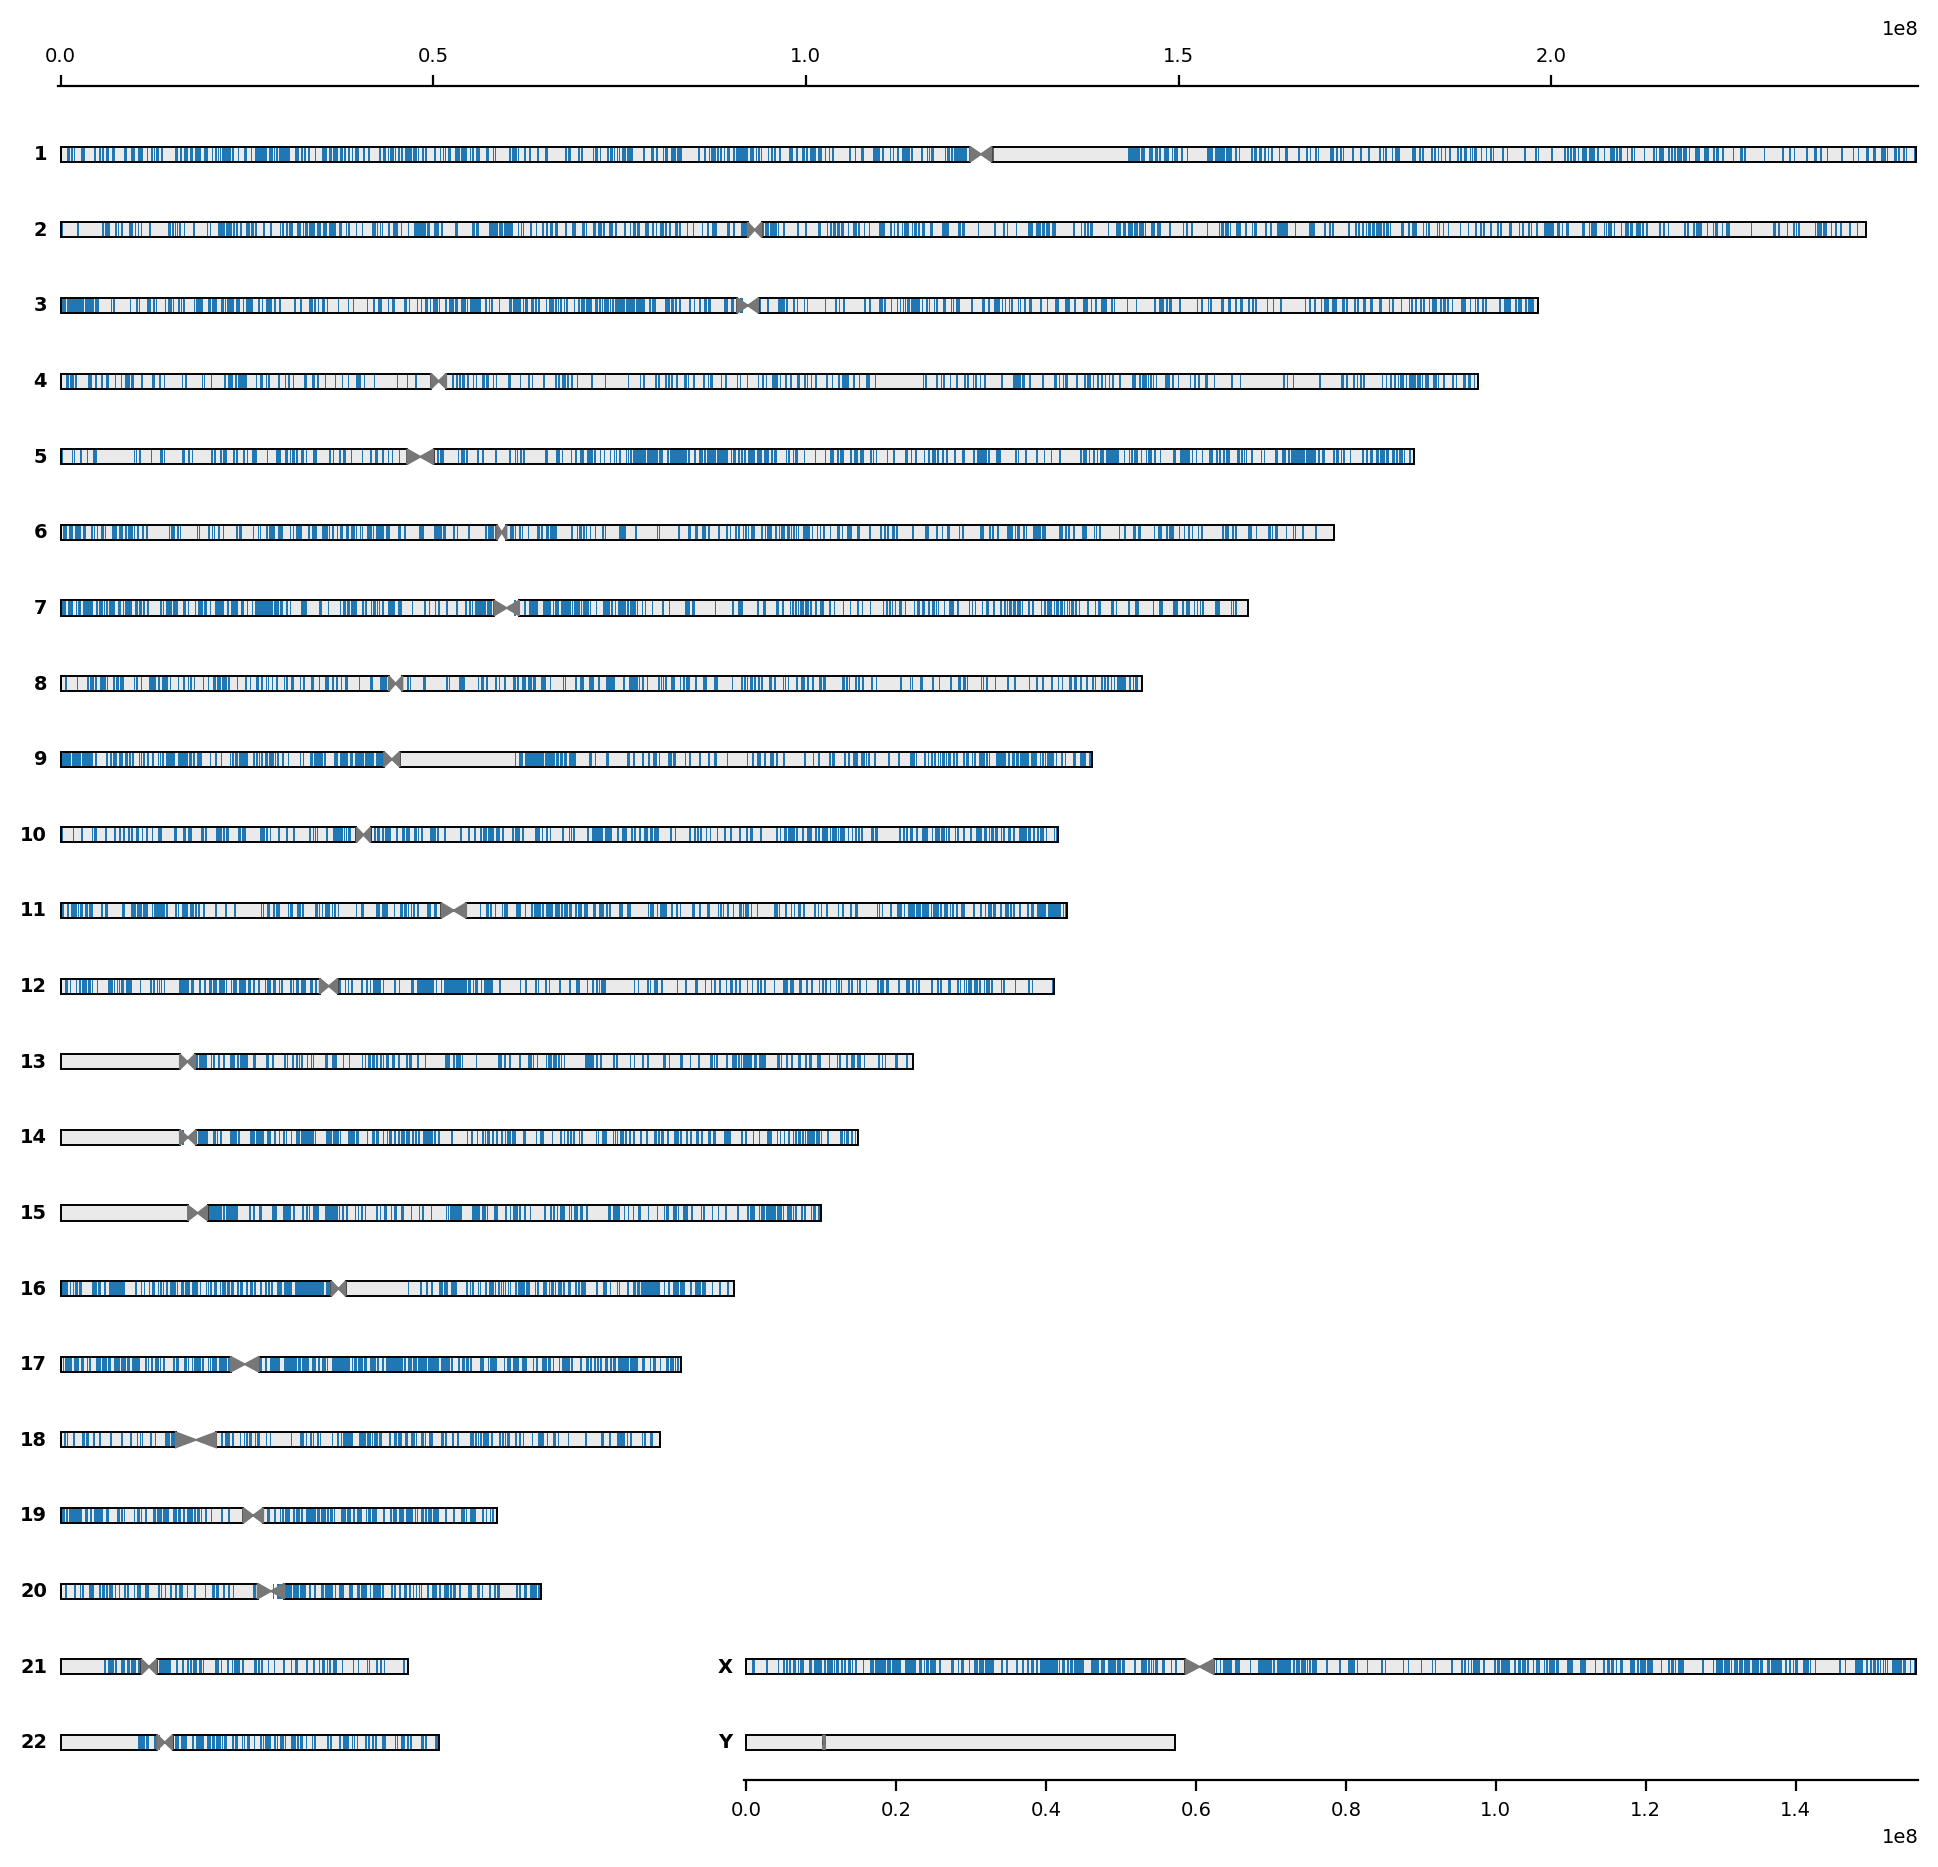

In [200]:
# Identify and visualize all ARs

all_ARs = overlap_counts[overlap_counts["num_lineages"] >= 1]  
print(all_ARs)

hotspots = [(row.Chr, row.Start, row.End) for row in all_ARs.itertuples(index=False)]
ideogram_plot = gplt.GenomeIdeogram(assembly='hg38') 
ideogram_plot.draw_chromosomes()
ideogram_plot.add_segments(hotspots, facecolor='tab:blue', alpha=0.2)

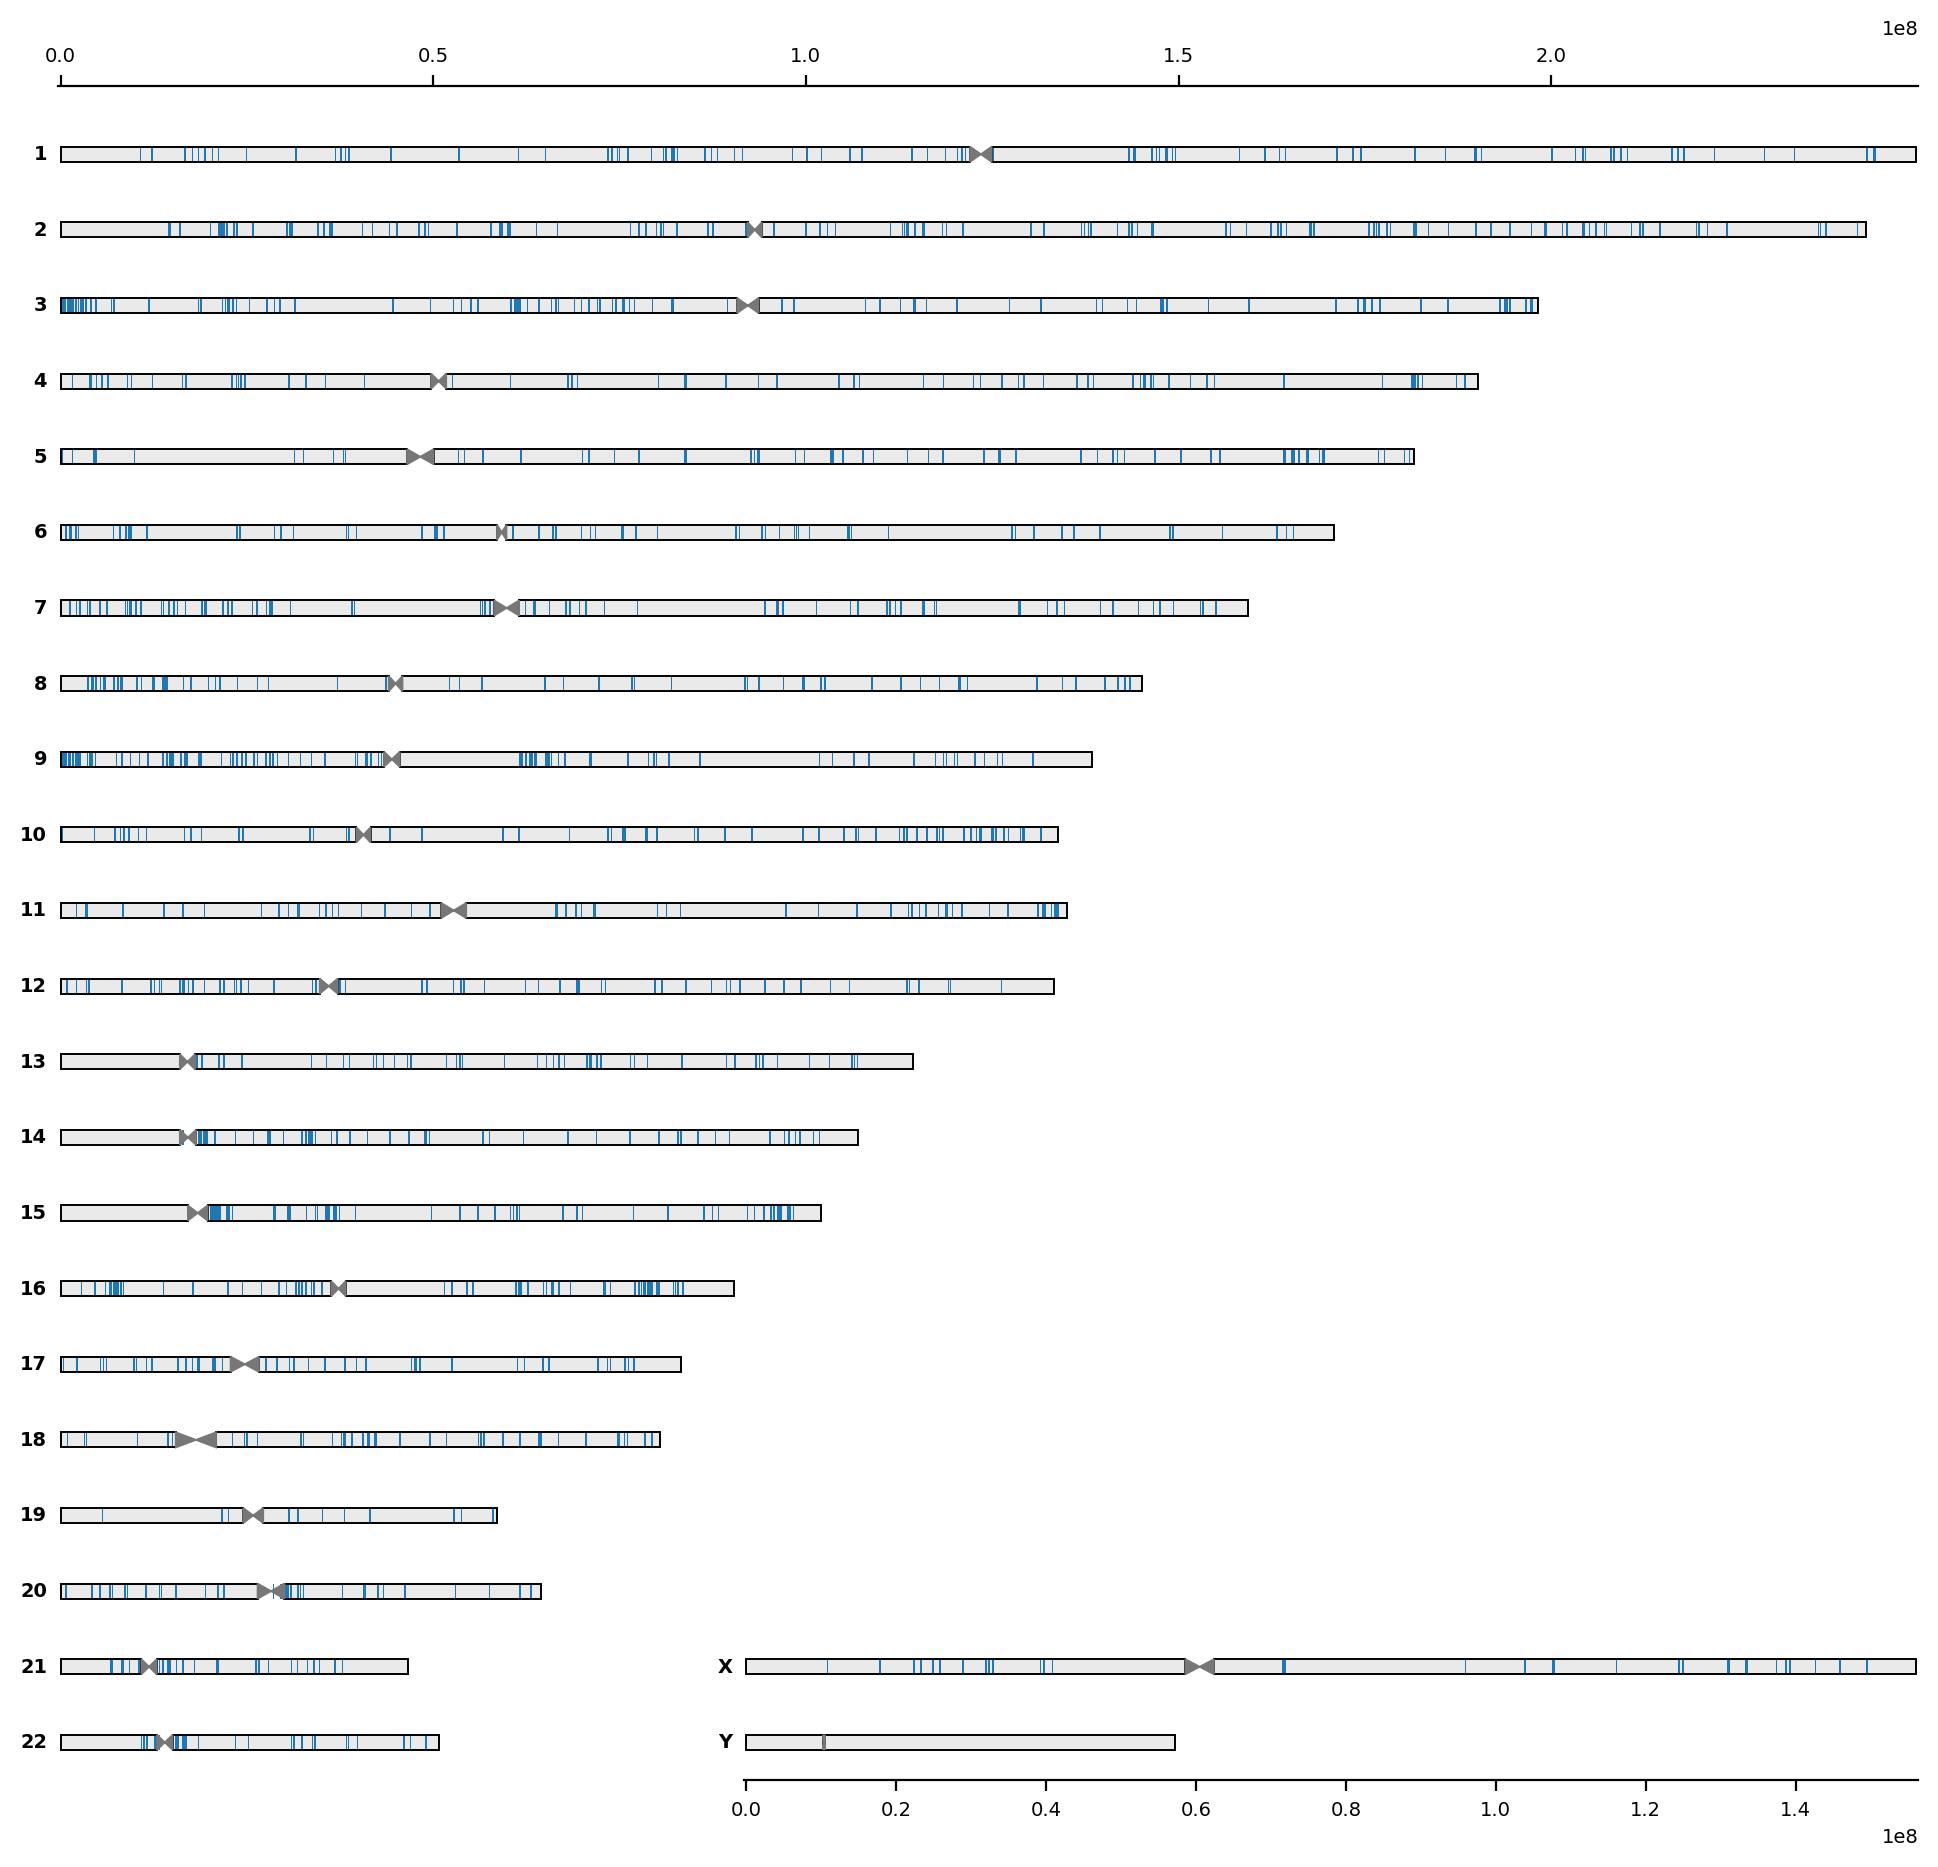

In [ ]:
# Identify and visualize all human ARs

hotspots = [(row.Chr, row.Start, row.End) for row in human_LinARs_df.itertuples(index=False)]
ideogram_plot = gplt.GenomeIdeogram(assembly='hg38') 
ideogram_plot.draw_chromosomes()
ideogram_plot.add_segments(hotspots, facecolor='tab:blue', alpha=0.2)

In [215]:
# Look up what the closest genes are to the very common ARs using apes_LinARs_df

very_common_ARs = overlap_counts[overlap_counts["num_lineages"] >= 7]  
#print(very_common_ARs)

# Merge on Chr, Start, End
annotated = very_common_ARs.merge(
    apes_LinARs_df[['Chr', 'Start', 'End', 'Gene_name', 'Lineage_name']],
    on=['Chr', 'Start', 'End'],
    how='left'
)

# Keep only unique combinations
unique_combinations = annotated[['Chr', 'Start', 'End', 'Gene_name', 'Lineage_name']].drop_duplicates()
unique_combinations = unique_combinations.sort_values(['Chr', 'Start', 'End'])
print(unique_combinations)


      Chr      Start        End Gene_name        Lineage_name
0    chr1  121397074  121397291   SRGAP2C               Human
1    chr1  121397074  121397291   SRGAP2C  Hylobates pileatus
2    chr1  121397074  121397291   SRGAP2C      Pongo pygmaeus
3    chr1  121397074  121397291   SRGAP2C        Pongo abelii
4    chr1  121397074  121397291   SRGAP2C        Pan paniscus
..    ...        ...        ...       ...                 ...
188  chr3  193155977  193157179    HRASLS         Hylobatidae
189  chr3  193155977  193157179    HRASLS     Gorilla gorilla
190  chr3  193155977  193157179    HRASLS            Ponginae
191  chr3  193155977  193157179    HRASLS  Hoolock leuconedys
192  chr3  193155977  193157179    HRASLS        Pan paniscus

[193 rows x 5 columns]


In [218]:
unique_combinations.style


,Chr,Start,End,Gene_name,Lineage_name
0,chr1,121397074,121397291,SRGAP2C,Human
1,chr1,121397074,121397291,SRGAP2C,Hylobates pileatus
2,chr1,121397074,121397291,SRGAP2C,Pongo pygmaeus
3,chr1,121397074,121397291,SRGAP2C,Pongo abelii
4,chr1,121397074,121397291,SRGAP2C,Pan paniscus
5,chr1,121397074,121397291,SRGAP2C,Pan troglodytes
6,chr1,121397074,121397291,SRGAP2C,Symphalangus syndactylus
7,chr14,16048008,16048425,NONE,Human
8,chr14,16048008,16048425,NONE,Gorilla gorilla
9,chr14,16048008,16048425,NONE,Hylobates pileatus


## HARs in ancestral nodes and other species

### See if a HAR is an AR in an ancestral node

In [177]:
# For each human LinAR, see if it is also an AR in an ancestral node

ancestral_nodes = ["Homininae", "Hominidae", "Hominoidea"]
human_LinARs = apes_LinARs_df[LinARs_df["Lineage_name"] == "Human"]
ancestral_LinARs = apes_LinARs_df[apes_LinARs_df["Lineage_name"].isin(ancestral_nodes)]


# Merge on Chr, Start, End to find shared coordinates
shared_LinARs = pd.merge(
    human_LinARs,
    ancestral_LinARs,
    on=["Chr", "Start", "End"],
    suffixes=("_human", "_ancestor")
)
print(f"Number of human-ancestor matches: {shared_LinARs.shape[0]}")

n_unique_shared = (
    shared_LinARs[["Chr", "Start", "End"]]
    .drop_duplicates()
)
print(f"Number of unique human accelerated regions found in ancestors: {n_unique_shared.shape[0]}")


Number of human-ancestor matches: 49
Number of unique human accelerated regions found in ancestors: 47


/var/folders/pz/y0tgvym13cg8yjfc14z454cr0000gn/T/ipykernel_31104/2134036498.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  human_LinARs = apes_LinARs_df[LinARs_df["Lineage_name"] == "Human"]


In [ ]:
# See if the shared accelerated regions have the same gene associated
set(shared_LinARs["Gene_name_human"]) == set(shared_LinARs["Gene_name_ancestor"])


True

In [179]:
# See genes shared_LinARs
shared_LinARs_genes = glist(shared_LinARs["Gene_name_human"].dropna().unique().tolist())
shared_LinARs_genes


NBPF9,NONE,OR11H12,RFX7,ZNF98,POTEH,HLA-C,OR1L3
PPIAL4C,KRT76,OR11H2,PRSS41,PMS1,IGLL1,THEMIS,AGTR2
FGF3,SDR9C7,RNASE4,AC098850.3,PASK,HRASLS,ZNF783,
MGST1,CLN5,POTEB2,SLFN12L,OR11H1,UGT2B15,TRBV20OR9-2,


Could not map gene symbol "NONE" to ncbi id
Could not map gene symbol "AL035078.4" to ncbi id
Could not map gene symbol "FAM86C1" to ncbi id
Could not map gene symbol "AC001226.2" to ncbi id
Could not map gene symbol "C14orf177" to ncbi id
Could not map gene symbol "IGHV4OR15-8" to ncbi id
Could not map gene symbol "FAM169B" to ncbi id
Could not map gene symbol "AC092338.1" to ncbi id
Could not map gene symbol "IGHV2OR16-5" to ncbi id
Could not map gene symbol "IGHV3OR16-8" to ncbi id
Could not map gene symbol "AC136428.1" to ncbi id
Could not map gene symbol "C17orf97" to ncbi id
Could not map gene symbol "AC098850.3" to ncbi id
Could not map gene symbol "ZNF286B" to ncbi id
Could not map gene symbol "C2orf91" to ncbi id
Could not map gene symbol "C2CD6" to ncbi id
Could not map gene symbol "SLC35C2" to ncbi id
Could not map gene symbol "AP000295.1" to ncbi id
Could not map gene symbol "AC097634.4" to ncbi id
Could not map gene symbol "AC098588.1" to ncbi id
Could not map gene symbol 

  namespace     term_id e/p  pval_uncorr  p_fdr_bh     ratio  bg_ratio  \
0        MF  GO:0004984   e     0.000022  0.018677  0.148148  0.008242   
1        MF  GO:0004930   e     0.000050  0.021814  0.185185  0.017857   
2        BP  GO:0007608   e     0.000022  0.033939  0.148148  0.008242   
3        BP  GO:0050911   e     0.000022  0.033939  0.148148  0.008242   

            obj  
0  <GO:0004984>  
1  <GO:0004930>  
2  <GO:0007608>  
3  <GO:0050911>  


**<span style="color:gray;">GO:0004984:</span>** **olfactory receptor activity**  
 Combining with an odorant and transmitting the signal from one side of the membrane to the other to initiate a change in cell activity in response to detection of smell.    

 ----

**<span style="color:gray;">GO:0004930:</span>** **G protein-coupled receptor activity**  
 Combining with an extracellular signal and transmitting the signal across the membrane by activating an associated G-protein; promotes the exchange of GDP for GTP on the alpha subunit of a heterotrimeric G-protein complex.    

 ----

**<span style="color:gray;">GO:0007608:</span>** **sensory perception of smell**  
 The series of events required for an organism to receive an olfactory stimulus, convert it to a molecular signal, and recognize and characterize the signal. Olfaction involves the detection of chemical composition of an organism's ambient medium by chemoreceptors. This is a neurological process.    

 ----

**<span style="color:gray;">GO:0050911:</span>** **detection of chemical stimulus involved in sensory perception of smell**  
 The series of events involved in the perception of smell in which an olfactory chemical stimulus is received and converted into a molecular signal.    

 ----

None


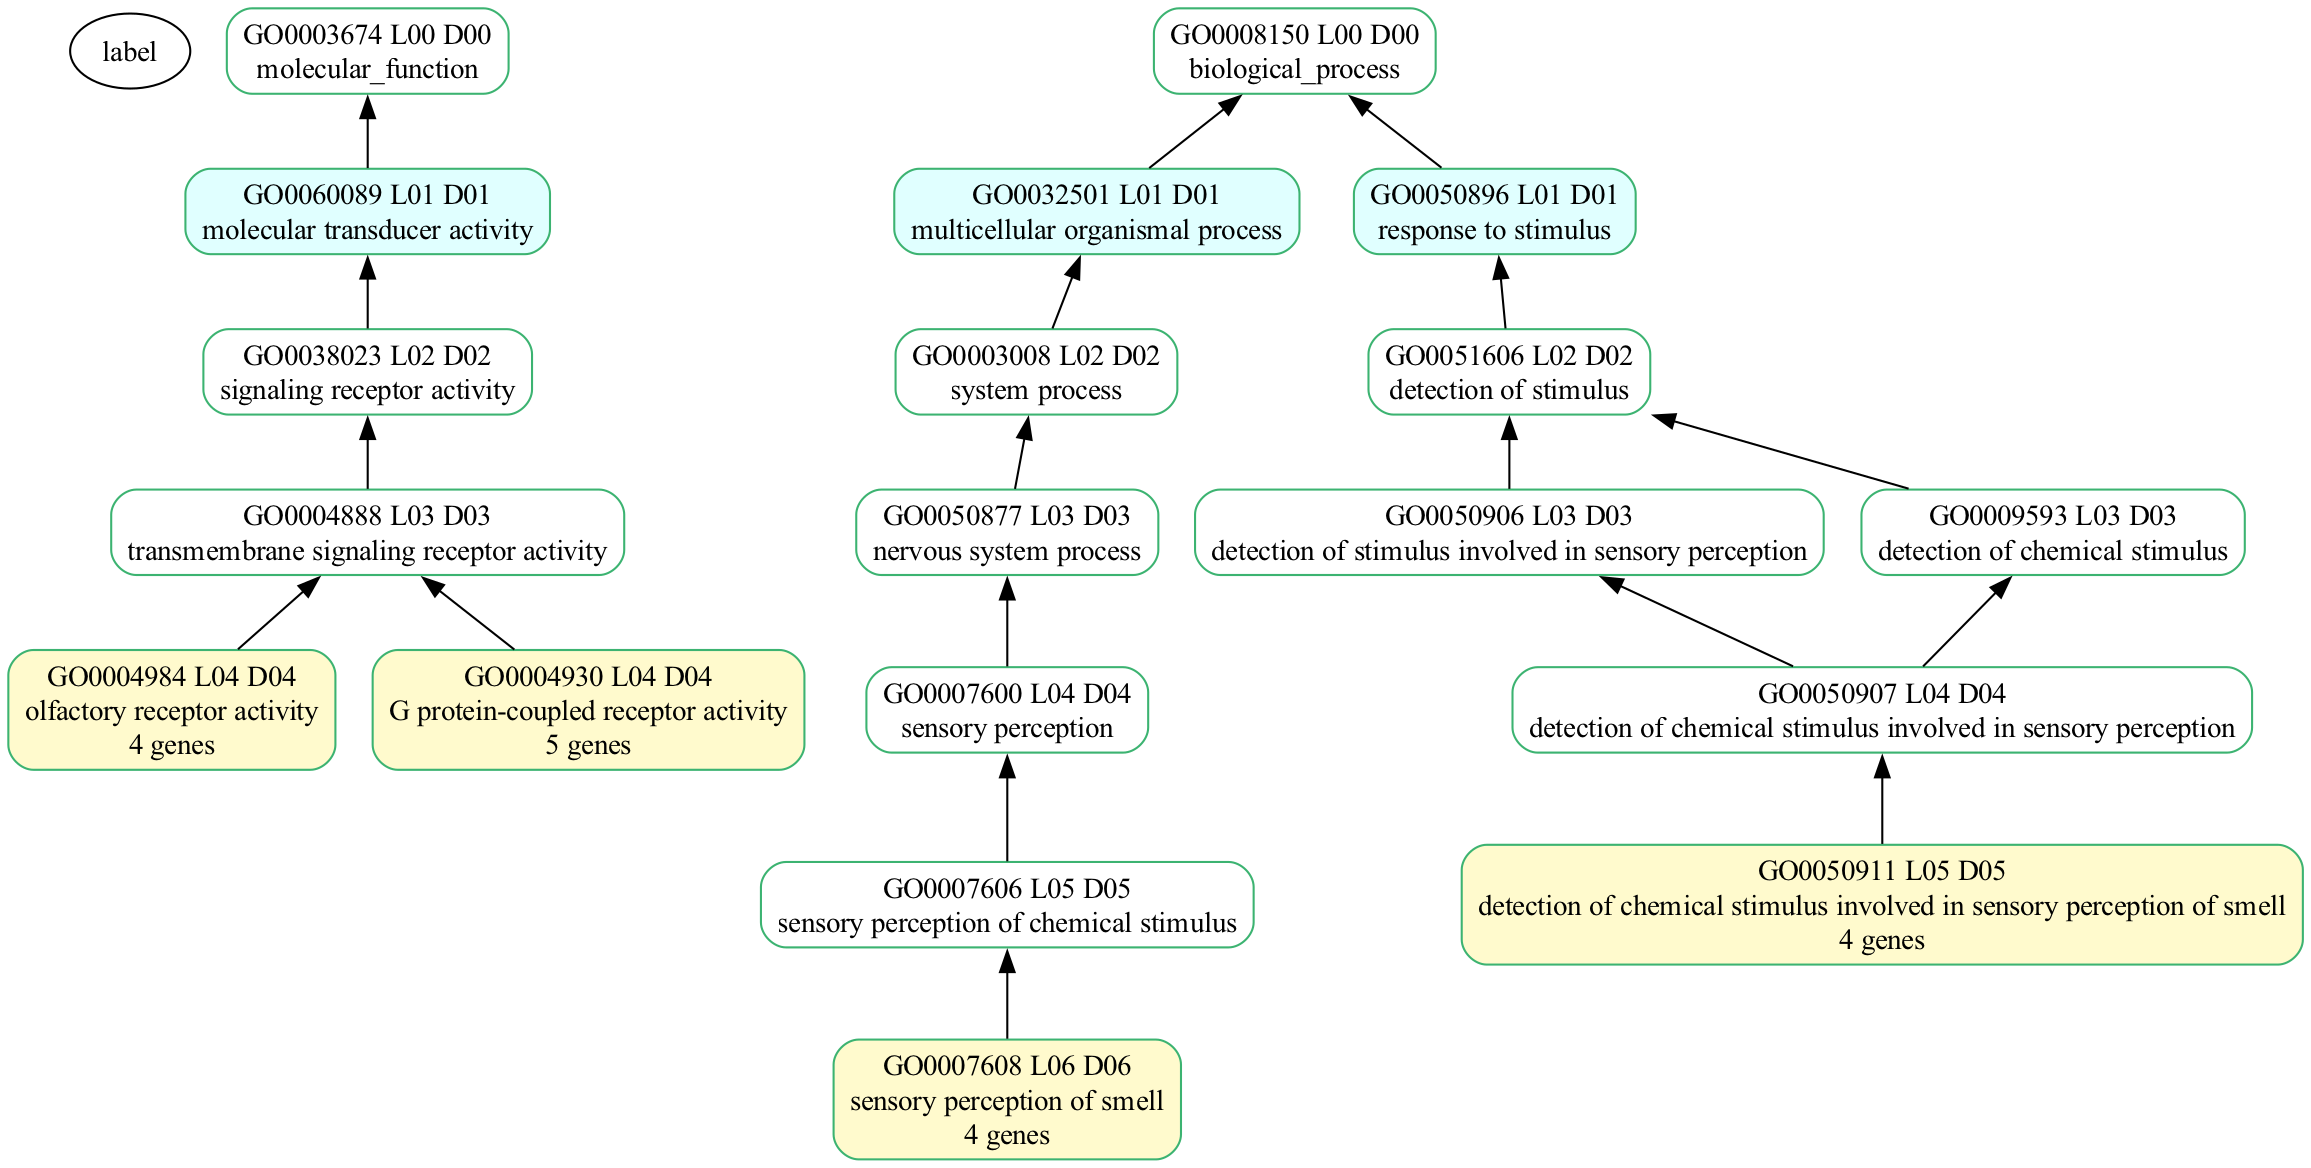

None


In [ ]:
# Enrichment analyses of genes in shared_LinARs_genes

background_genes = glist(apes_LinARs_df.loc[apes_LinARs_df["Lineage_name"] == "Human", "Gene_name"].dropna().unique().tolist())

# GO enrichment of shared_LinARs
go_results = go.go_enrichment(shared_LinARs_genes, background_genes = background_genes)

# Top GO results
print(go_results.head(10)) 
print(go.go_info(go_results.term_id[:10])) 
print(go.show_go_dag_enrichment_results(go_results.obj[:10]))


### See if a HAR is found in another ape

In [183]:
# For each human LinAR, see if it exist in another ape

apes_ancestors_excluded = [
    "Pan troglodytes", "Pan paniscus", "Gorilla gorilla",
    "Pongo abelii", "Pongo pygmaeus", "Nomascus siki",
    "Symphalangus syndactylus", "Hoolock leuconedys", "Hylobates pileatus"
]

ape_species_LinARs = apes_LinARs_df[LinARs_df["Lineage_name"].isin(apes_ancestors_excluded)]

# Merge on Chr, Start, End to find shared coordinates
shared_LinARs = pd.merge(
    human_LinARs,
    ape_species_LinARs,
    on=["Chr", "Start", "End"],
    suffixes=("_human", "_ape")
)


print(f"Number of human-ape matches: {shared_LinARs.shape[0]}")

n_unique_shared = (
    shared_LinARs[["Chr", "Start", "End"]]
    .drop_duplicates()
)
print(f"Number of unique human accelerated regions found in ape species: {n_unique_shared.shape[0]}")




Number of human-ape matches: 549
Number of unique human accelerated regions found in ape species: 259


/var/folders/pz/y0tgvym13cg8yjfc14z454cr0000gn/T/ipykernel_31104/147690563.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ape_species_LinARs = apes_LinARs_df[LinARs_df["Lineage_name"].isin(apes_ancestors_excluded)]


Could not map gene symbol "NONE" to ncbi id
Could not map gene symbol "AL035078.4" to ncbi id
Could not map gene symbol "FAM86C1" to ncbi id
Could not map gene symbol "AC001226.2" to ncbi id
Could not map gene symbol "C14orf177" to ncbi id
Could not map gene symbol "IGHV4OR15-8" to ncbi id
Could not map gene symbol "FAM169B" to ncbi id
Could not map gene symbol "AC092338.1" to ncbi id
Could not map gene symbol "IGHV2OR16-5" to ncbi id
Could not map gene symbol "IGHV3OR16-8" to ncbi id
Could not map gene symbol "AC136428.1" to ncbi id
Could not map gene symbol "C17orf97" to ncbi id
Could not map gene symbol "AC098850.3" to ncbi id
Could not map gene symbol "ZNF286B" to ncbi id
Could not map gene symbol "C2orf91" to ncbi id
Could not map gene symbol "C2CD6" to ncbi id
Could not map gene symbol "SLC35C2" to ncbi id
Could not map gene symbol "AP000295.1" to ncbi id
Could not map gene symbol "AC097634.4" to ncbi id
Could not map gene symbol "AC098588.1" to ncbi id
Could not map gene symbol 

  namespace     term_id e/p  pval_uncorr  p_fdr_bh     ratio  bg_ratio  \
0        MF  GO:0005515   p     0.000029  0.024733  0.467391  0.666209   

            obj  
0  <GO:0005515>  


**<span style="color:gray;">GO:0005515:</span>** **protein binding**  
 Binding to a protein.    

 ----

None


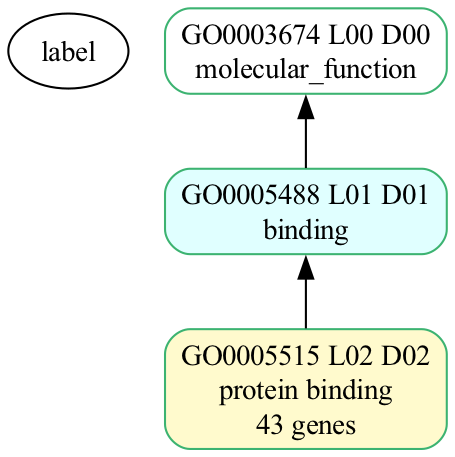

None


In [184]:
# Enrichment analyses of genes in shared_LinARs_genes

shared_LinARs_genes = glist(shared_LinARs["Gene_name_human"].dropna().unique().tolist())

background_genes = glist(apes_LinARs_df.loc[apes_LinARs_df["Lineage_name"] == "Human", "Gene_name"].dropna().unique().tolist())

# GO enrichment of shared_LinARs
go_results = go.go_enrichment(shared_LinARs_genes, background_genes = background_genes)

# Top GO results
print(go_results.head(10)) 
print(go.go_info(go_results.term_id[:10])) 
print(go.show_go_dag_enrichment_results(go_results.obj[:10]))

           Lineage_name_ape  count
0           Pan troglodytes    119
1              Pan paniscus     96
2           Gorilla gorilla     71
3              Pongo abelii     55
4            Pongo pygmaeus     54
5  Symphalangus syndactylus     44
6             Nomascus siki     39
7        Hylobates pileatus     39
8        Hoolock leuconedys     32


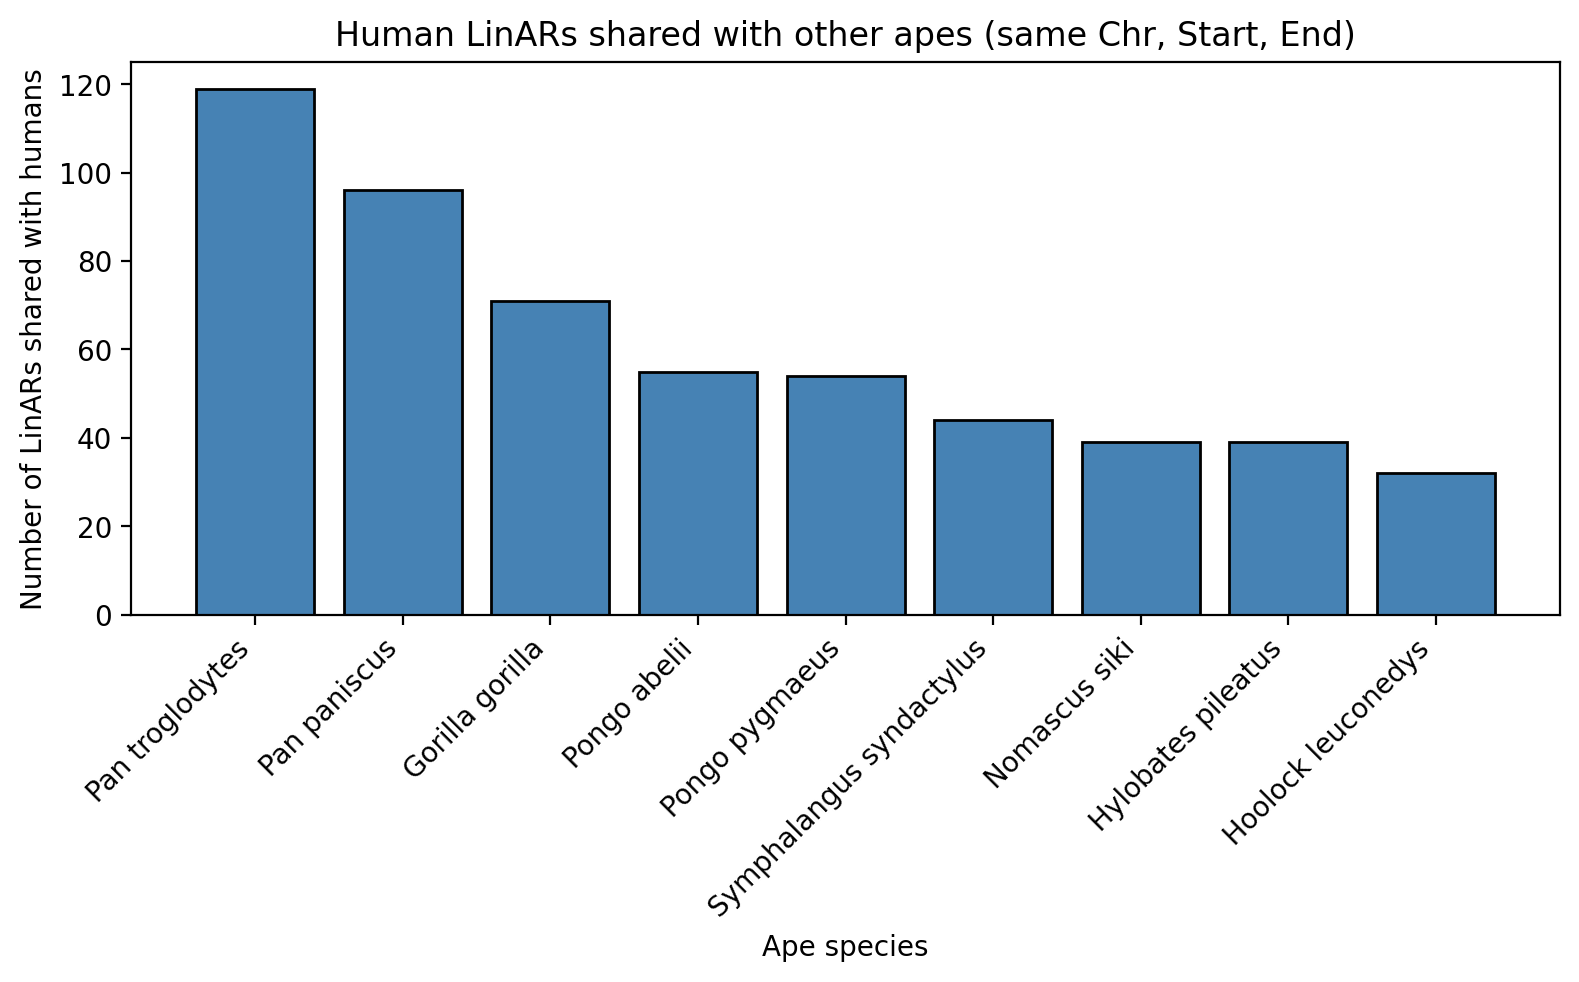

In [192]:
# Visualize which apes have LinARs that overlap with human LinARs

# Count how many shared LinARs per ape lineage
ape_counts = shared_LinARs["Lineage_name_ape"].value_counts().reset_index()
print(ape_counts)

plt.figure(figsize=(8,5))
plt.bar(ape_counts["Lineage_name_ape"], ape_counts["count"], color="steelblue", edgecolor="black")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of LinARs shared with humans")
plt.xlabel("Ape species")
plt.title("Human LinARs shared with other apes (same Chr, Start, End)")
plt.tight_layout()
plt.show()


### Does the same gene associated with a HAR have an associated LinAR in another ape?

Number of genes associated with human LinARs: 758
               Lineage_name  Num_shared_genes
0           Gorilla gorilla                78
1        Hoolock leuconedys               187
2        Hylobates pileatus                75
3             Nomascus siki               145
4              Pan paniscus               131
5           Pan troglodytes               125
6              Pongo abelii                75
7            Pongo pygmaeus                94
8  Symphalangus syndactylus                76


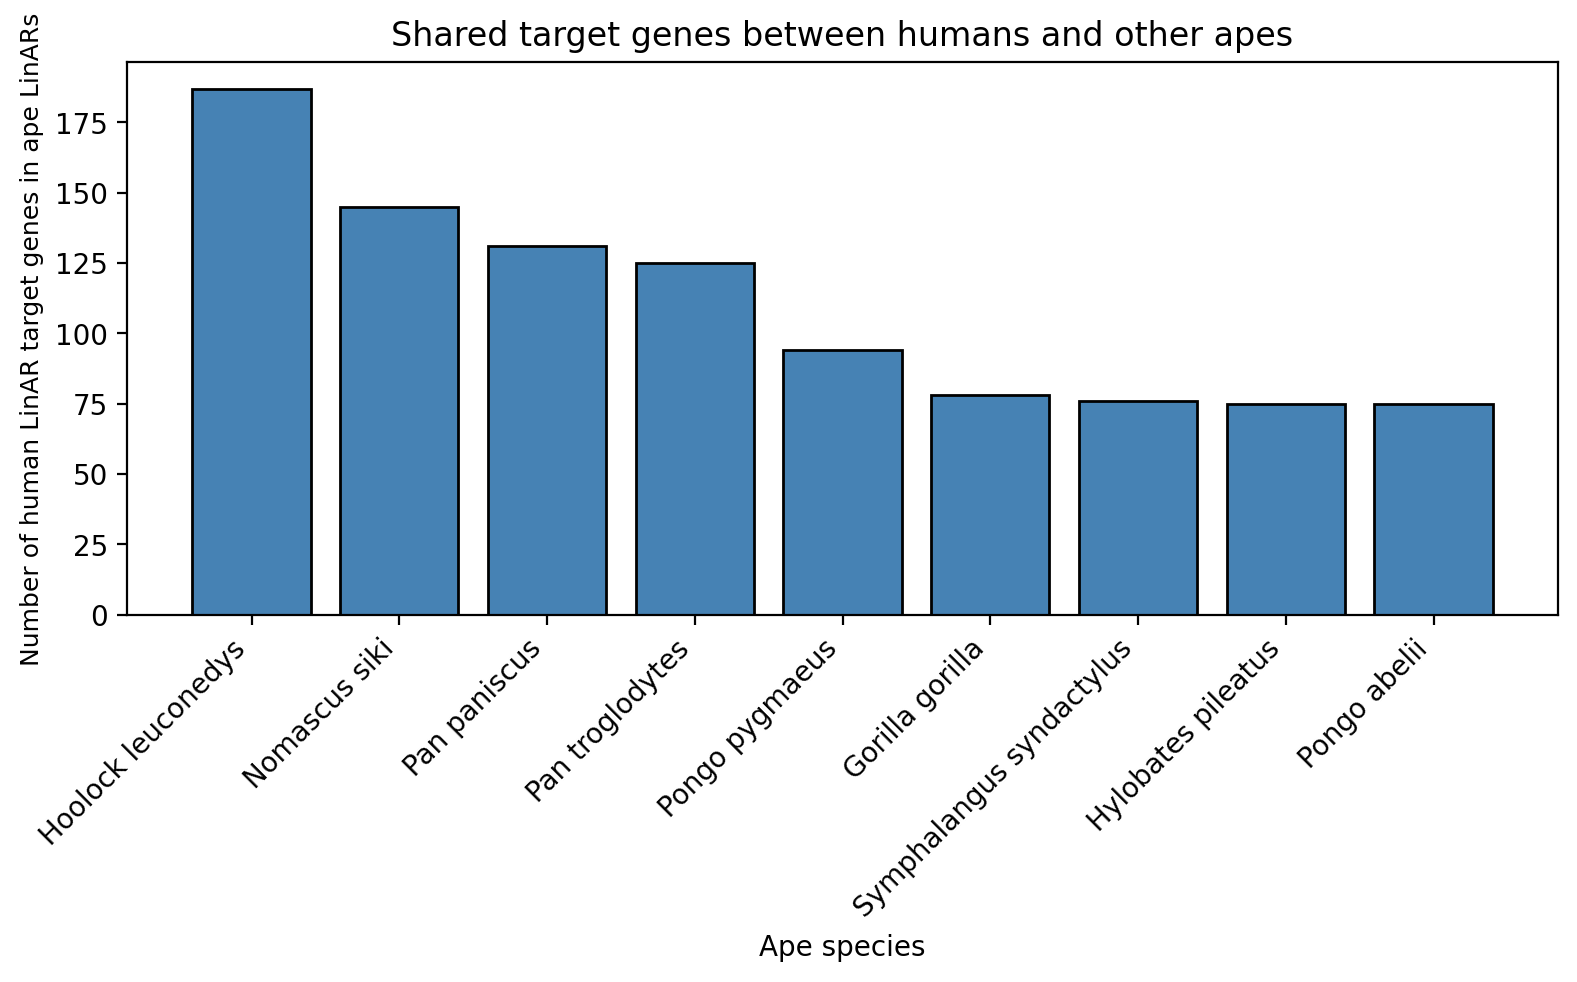

In [195]:
# Are the genes associated with human LinARs also associated with LinARs in other apes?


# Unique genes associated with human LinARs
human_LinARs = human_LinARs[human_LinARs["Gene_name"] != "NONE"]
human_genes = set(human_LinARs["Gene_name"].dropna().unique())
ape_genes = ape_species_LinARs[ape_species_LinARs["Gene_name"].isin(human_genes)]
print(f"Number of genes associated with human LinARs: {len(human_genes)}")

# Keep only ape LinARs which associated gene exist in HAR target genes
ape_linars_with_har_targets = ape_species_LinARs[ape_species_LinARs["Gene_name"].isin(human_genes)]

# Count of ape LinARs targeting human LinAR genes per species
ape_gene_counts = (
    ape_linars_with_har_targets.groupby("Lineage_name")["Gene_name"]
    .nunique() 
    .reset_index(name="Num_shared_genes")
)
print(ape_gene_counts)

ape_gene_counts = ape_gene_counts.sort_values("Num_shared_genes", ascending=False)
plt.figure(figsize=(8,5))
plt.bar(ape_gene_counts["Lineage_name"], ape_gene_counts["Num_shared_genes"], color="steelblue", edgecolor="black")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of human LinAR target genes in ape LinARs", fontsize = 9)
plt.xlabel("Ape species")
plt.title("Shared target genes between humans and other apes")
plt.tight_layout()
plt.show()

### Enrichment analysis of unique shared ARs

Could not map gene symbol "NONE" to ncbi id
Could not map gene symbol "YARS" to ncbi id
Could not map gene symbol "AC239811.1" to ncbi id
Could not map gene symbol "AC242843.1" to ncbi id
Could not map gene symbol "GBA" to ncbi id
Could not map gene symbol "AL590132.1" to ncbi id
Could not map gene symbol "AL445423.2" to ncbi id
Could not map gene symbol "C10orf113" to ncbi id
Could not map gene symbol "CASC10" to ncbi id
Could not map gene symbol "FO681492.1" to ncbi id
Could not map gene symbol "AL035078.4" to ncbi id
Could not map gene symbol "FAM86C1" to ncbi id
Could not map gene symbol "AC073610.3" to ncbi id
Could not map gene symbol "AC073611.1" to ncbi id
Could not map gene symbol "AC012531.3" to ncbi id
Could not map gene symbol "AC097104.1" to ncbi id
Could not map gene symbol "AC048338.1" to ncbi id
Could not map gene symbol "AC068790.8" to ncbi id
Could not map gene symbol "AL359736.1" to ncbi id
Could not map gene symbol "AC001226.2" to ncbi id
Could not map gene symbol "

  namespace     term_id e/p  pval_uncorr  p_fdr_bh     ratio  bg_ratio  \
0        MF  GO:0016018   e     0.000002  0.004428  0.014523  0.001913   
1        MF  GO:0003755   e     0.000008  0.008972  0.014523  0.002153   

            obj  
0  <GO:0016018>  
1  <GO:0003755>  


**<span style="color:gray;">GO:0016018:</span>** **cyclosporin A binding**  
 Binding to cyclosporin A, a cyclic undecapeptide that contains several N-methylated and unusual amino acids.    

 ----

**<span style="color:gray;">GO:0003755:</span>** **peptidyl-prolyl cis-trans isomerase activity**  
 Catalysis of the reaction: peptidyl-proline (omega=180) = peptidyl-proline (omega=0).    

 ----

None


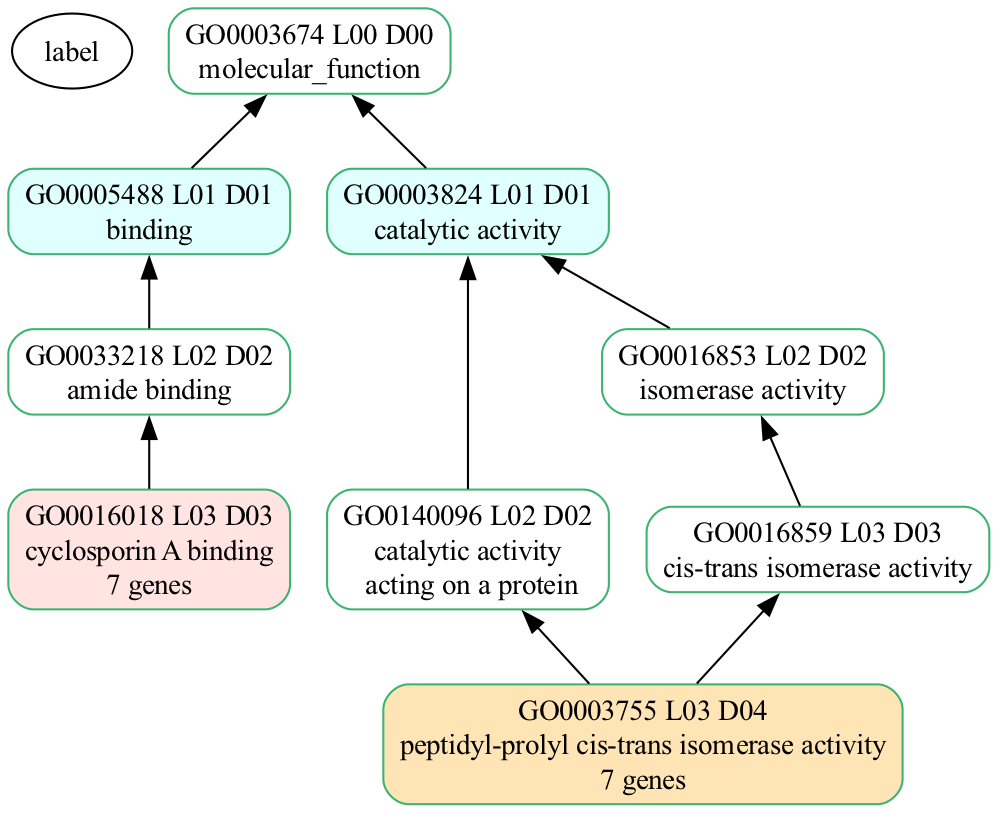

None


In [199]:
# Count unique lineages per LinAR
linar_counts = (
    apes_LinARs_df.groupby(["Chr", "Start", "End"])["Lineage_name"]
    .nunique()
    .reset_index()
    .rename(columns={"Lineage_name": "Lineage_count"})
)

# Filter LinARs shared by at least 2 lineages
shared_linars = linar_counts[linar_counts["Lineage_count"] >= 2]

# Merge back to get associated genes
shared_linars_df = apes_LinARs_df.merge(shared_linars, on=["Chr", "Start", "End"])
shared_linars_genes = shared_linars_df["Gene_name"].dropna().unique().tolist()
# Rremove "NONE"
shared_linars_genes = [gene for gene in shared_linars_genes if gene != "NONE"]


# GO enrichment of shared LinAR genes
background_genes = apes_LinARs_df["Gene_name"].dropna().unique().tolist() #background genes are all genes associated with ape LinARs
go_results = go.go_enrichment(shared_linars_genes, background_genes=background_genes)

# Top GO results
print(go_results.head(10))
print(go.go_info(go_results.term_id[:10]))
print(go.show_go_dag_enrichment_results(go_results.obj[:10]))
